# Đồ án : Phân cụm dữ liệu biểu hiện gen với ensemble model

EDA - EXPLORATORY DATA ANALYSIS

BƯỚC 1: LOAD DATA VÀ HIỂU SHAPE

📊 SHAPE CỦA DATASET:
   - Số dòng (samples): 64
   - Số cột (features + metadata): 22,285
   - Kích thước: 64 samples × 22,285 columns

📋 THÔNG TIN CÁC CỘT:
   - 5 cột đầu tiên: ['samples', 'type', '1007_s_at', '1053_at', '117_at']
   - 5 cột cuối cùng: ['AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at']

📌 CÁC CỘT METADATA TÌM THẤY: ['samples', 'type']

📊 PHÂN TÍCH CỘT 'type' (Nhãn phân loại):
   - Số classes: 5
   - Các classes: ['AML', 'Bone_Marrow', 'Bone_Marrow_CD34', 'PB', 'PBSC_CD34']

   Phân bố samples theo class:
     • AML: 26 samples (40.6%)
     • PB: 10 samples (15.6%)
     • Bone_Marrow: 10 samples (15.6%)
     • PBSC_CD34: 10 samples (15.6%)
     • Bone_Marrow_CD34: 8 samples (12.5%)


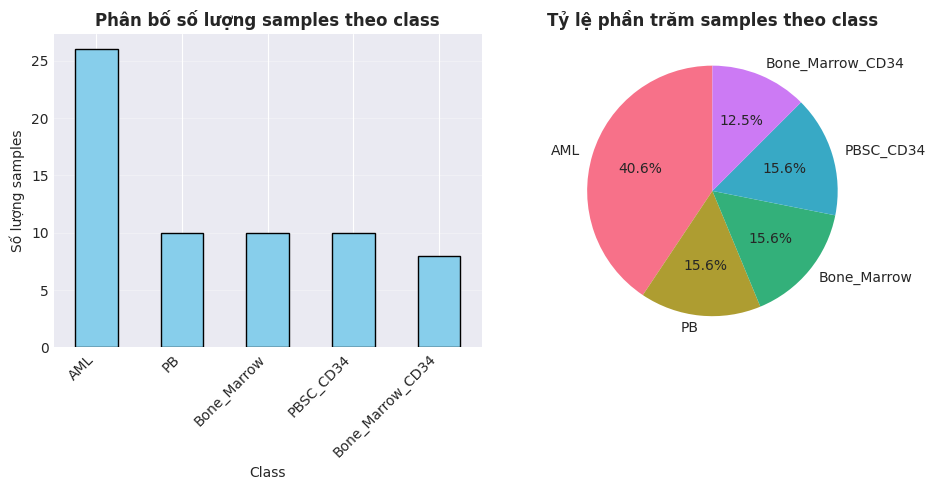


🧬 SỐ GEN (FEATURES):
   - Tổng số cột gene expression: 22,283
   - Cột AFFX (control probes): 68
   - Cột gen thật: 22,215

BƯỚC 2: KIỂM TRA MISSING VALUES

🔍 TỔNG QUAN MISSING VALUES:
   - Tổng số giá trị missing: 0
   - Tỷ lệ missing: 0.0000%

   ✓ KHÔNG CÓ MISSING VALUES - Dữ liệu sạch!

BƯỚC 3: PHÂN TÍCH DISTRIBUTION (PHÂN PHỐI DỮ LIỆU)

📊 PHÂN TÍCH 22,283 GEN:

📈 Thống kê mô tả cho 10 gen đầu tiên:
       1007_s_at  1053_at   117_at   121_at  1255_g_at  1294_at  1316_at  \
count    64.0000  64.0000  64.0000  64.0000    64.0000  64.0000  64.0000   
mean      7.8194   6.7505   7.4756   8.8989     4.5134   8.2826   5.5445   
std       0.1698   0.3754   1.3083   0.2085     0.0968   0.4086   0.1404   
min       7.2781   6.1033   6.2970   8.4863     4.3512   7.3314   5.2957   
25%       7.7012   6.5033   6.6402   8.7653     4.4492   8.0158   5.4545   
50%       7.8148   6.7244   6.7942   8.8710     4.5098   8.2300   5.5470   
75%       7.9604   6.9293   7.8881   9.0234     4.5676   8.5

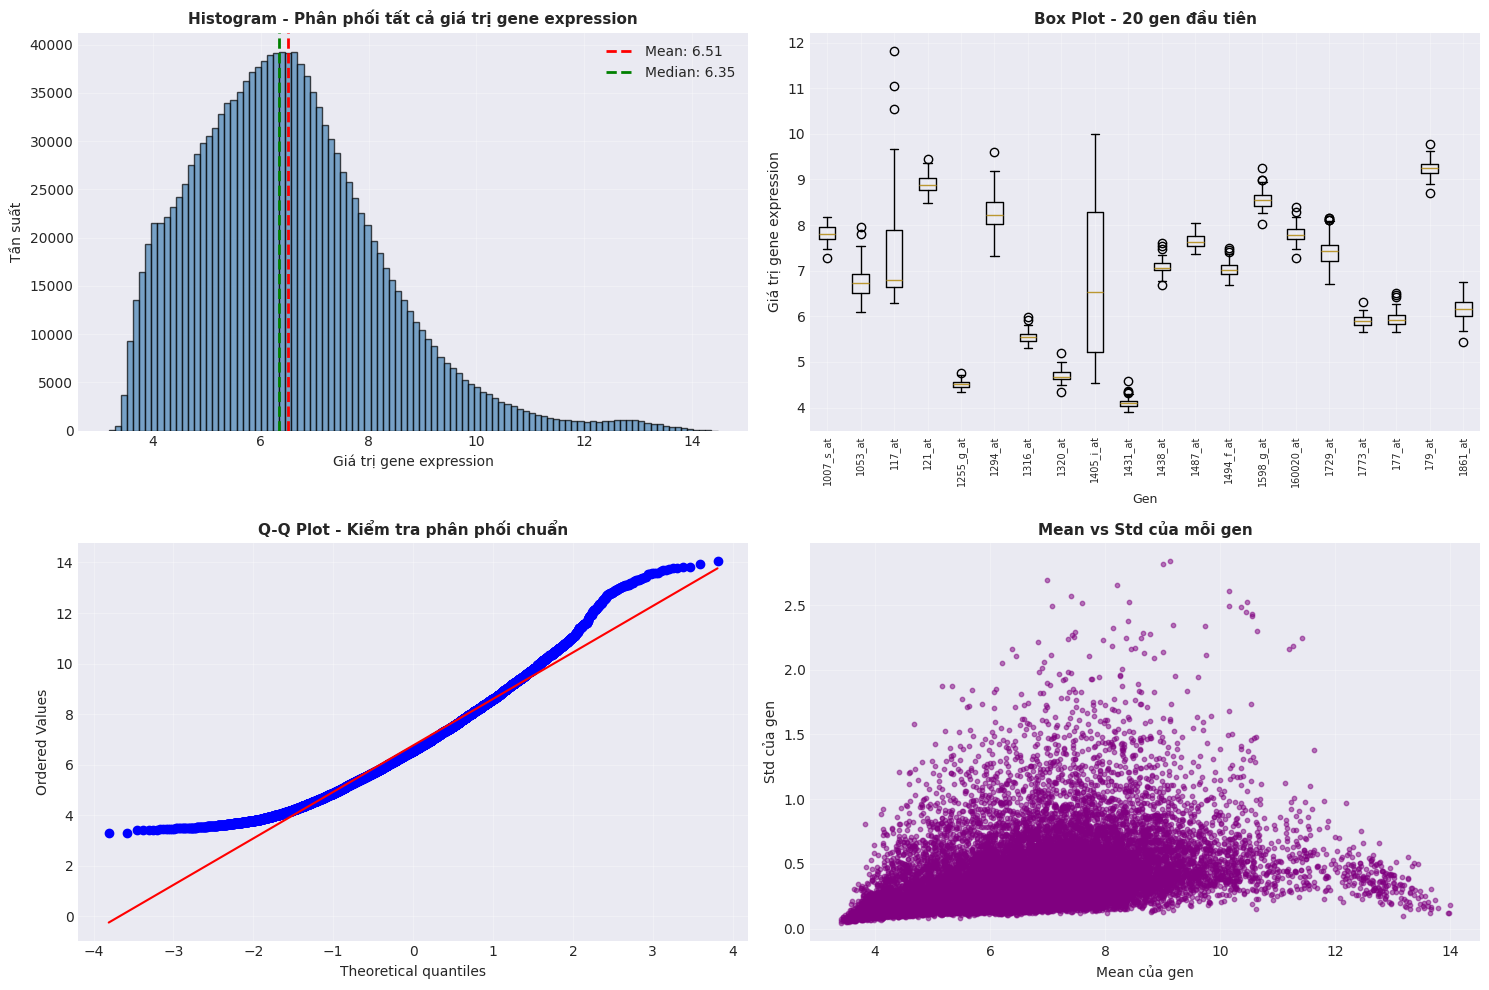


BƯỚC 4: PHÁT HIỆN OUTLIERS

🔍 PHÁT HIỆN OUTLIERS (IQR Method):
   - Q1 (25th percentile): 5.2451
   - Q3 (75th percentile): 7.4972
   - IQR: 2.2521
   - Lower bound: 1.8670
   - Upper bound: 10.8753
   - Số outliers: 27,451 (1.92%)

🔍 PHÁT HIỆN OUTLIERS (Z-score Method, |Z| > 3):
   - Số outliers: 16,719 (1.17%)


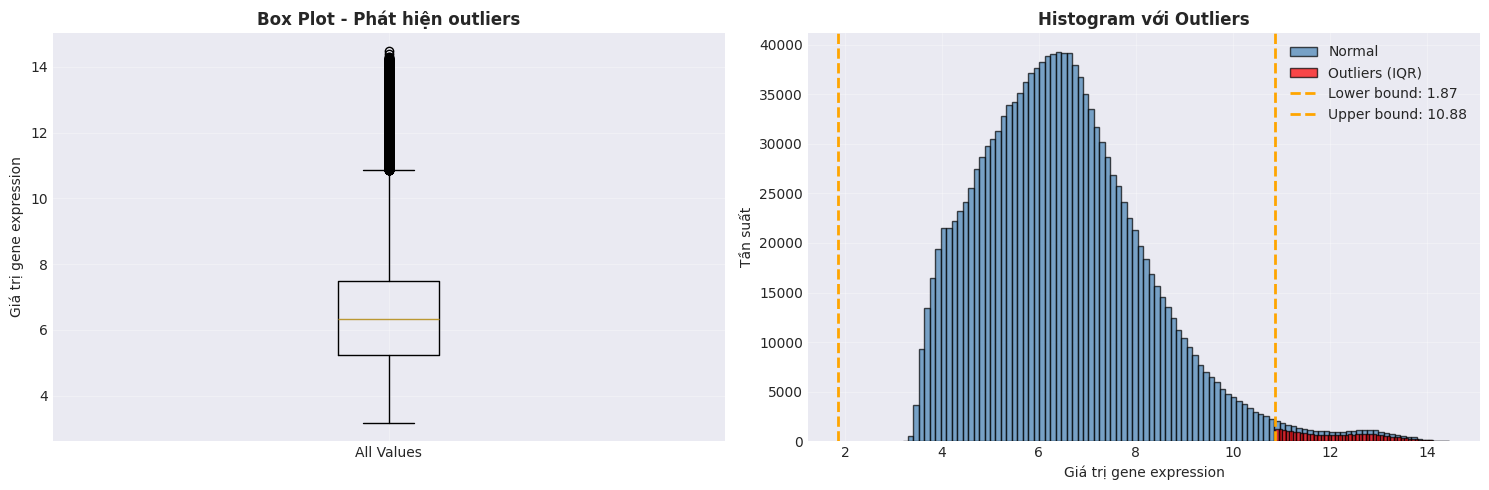


BƯỚC 5: KIỂM TRA SCALE (THANG ĐO)

📊 THỐNG KÊ SCALE CỦA CÁC GEN:
   - Mean của các gen:
     • Min mean: 3.4040
     • Max mean: 13.9882
     • Std của means: 1.6706
   - Std của các gen:
     • Min std: 0.0470
     • Max std: 2.8403
     • Mean của stds: 0.3669

⚠️  ĐÁNH GIÁ:
   - ⚠️  CÁC GEN CÓ THANG ĐO KHÁC NHAU ĐÁNG KỂ!
   - Range của means: 10.58
   - Range của stds: 2.79
   - → CẦN CHUẨN HÓA (Standardization/Normalization) trước khi clustering


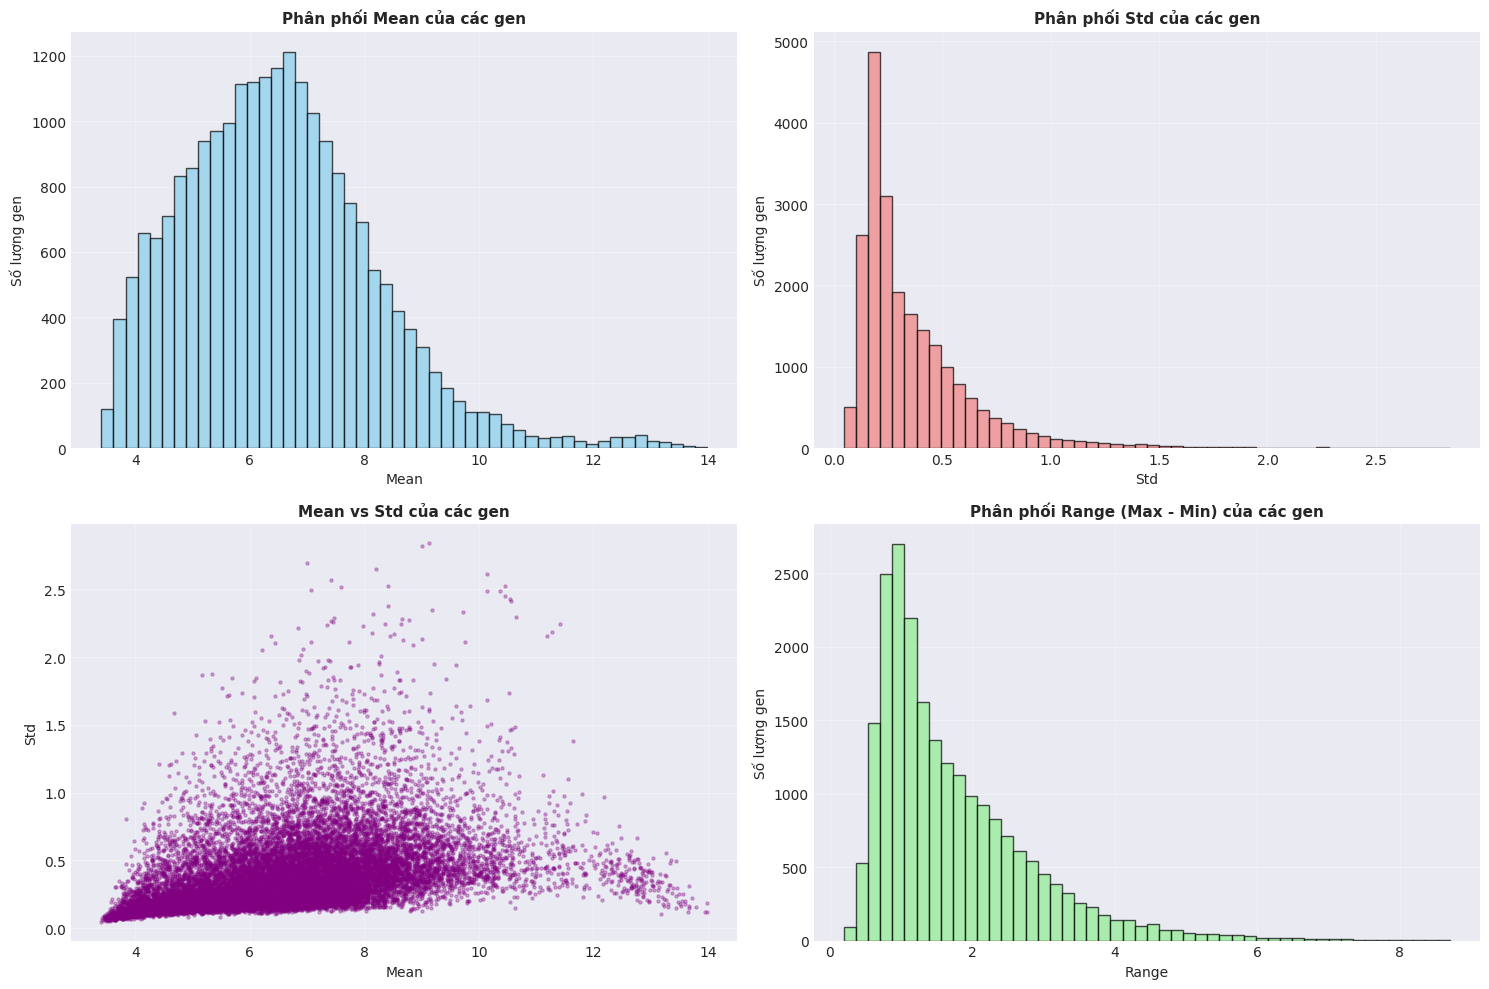


BƯỚC 6: PHÂN TÍCH VARIANCE (CHO CLUSTERING)

📊 PHÂN TÍCH VARIANCE:
   - Variance min: 0.002212
   - Variance max: 8.067324
   - Variance mean: 0.210557
   - Variance median: 0.073928

   Với threshold = 0.01:
   - Gen có variance thấp (< 0.01): 437 (1.96%)
   - Gen có variance cao (≥ 0.01): 21,846 (98.04%)

   💡 Gen có variance thấp không có thông tin phân biệt → nên loại bỏ


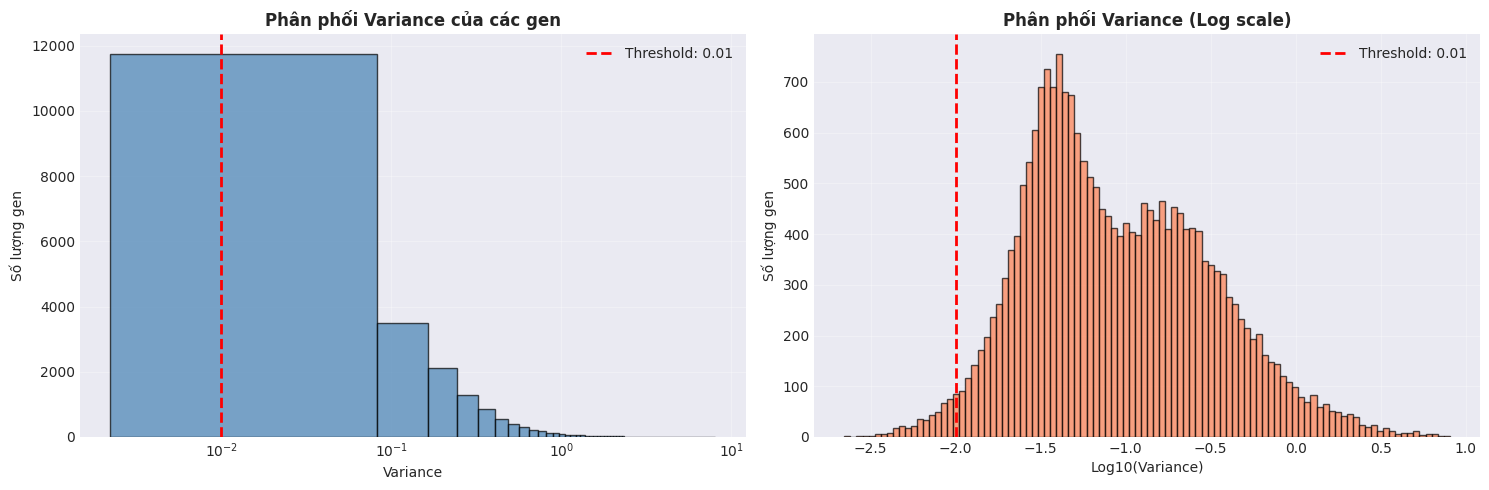


TÓM TẮT EDA - KẾT LUẬN

📋 TÓM TẮT:

1. SHAPE:
   - Dataset: 64 samples × 22,285 columns
   - Số gen thật: ~22,215
   - Số classes: 5

2. MISSING VALUES:
   - ✓ Không có missing values

3. DISTRIBUTION:
   - Mean: 6.5053, Median: 6.3479
   - Skewness: 0.8067 (Lệch phải)
   - Kurtosis: 1.0469

4. OUTLIERS:
   - IQR method: 27,451 outliers (1.92%)
   - Z-score method: 16,719 outliers (1.17%)

5. SCALE:
   - ⚠️ Cần chuẩn hóa
   - Range của means: 10.58
   - Range của stds: 2.79

6. VARIANCE:
   - 437 gen có variance thấp → nên loại bỏ
   - 21,846 gen có variance cao → giữ lại

💡 KHUYẾN NGHỊ CHO CLUSTERING:
   1. Loại bỏ metadata columns (samples, type)
   2. Loại bỏ AFFX control probes
   3. Loại bỏ gen có variance thấp
   4. Chuẩn hóa dữ liệu (StandardScaler)
   5. Giảm chiều với PCA (từ ~22k genes → 50-100 components)


KẾT THÚC EDA - SẴN SÀNG CHO CLEAN DATA VÀ CLUSTERING


In [19]:
# =================================================================================
# EDA - EXPLORATORY DATA ANALYSIS (KHAI PHÁ DỮ LIỆU)
# =================================================================================
# Mục tiêu: Hiểu rõ dữ liệu trước khi làm clustering
# Các bước: Shape, Missing values, Distribution, Outliers, Scale, Visualization

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style cho plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 100)
print("EDA - EXPLORATORY DATA ANALYSIS")
print("=" * 100)

# =================================================================================
# BƯỚC 1: LOAD DATA VÀ HIỂU SHAPE
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 1: LOAD DATA VÀ HIỂU SHAPE")
print("=" * 100)

file_path = "./Leukemia.csv"
df = pd.read_csv(file_path)

print(f"\n📊 SHAPE CỦA DATASET:")
print(f"   - Số dòng (samples): {df.shape[0]:,}")
print(f"   - Số cột (features + metadata): {df.shape[1]:,}")
print(f"   - Kích thước: {df.shape[0]:,} samples × {df.shape[1]:,} columns")

print(f"\n📋 THÔNG TIN CÁC CỘT:")
print(f"   - 5 cột đầu tiên: {list(df.columns[:5])}")
print(f"   - 5 cột cuối cùng: {list(df.columns[-5:])}")

# Kiểm tra các cột metadata
metadata_cols = ['samples', 'type', 'label', 'class', 'Class']
found_metadata = [c for c in metadata_cols if c in df.columns]
print(f"\n📌 CÁC CỘT METADATA TÌM THẤY: {found_metadata}")

# Phân tích cột type (nếu có)
if 'type' in df.columns:
    print(f"\n📊 PHÂN TÍCH CỘT 'type' (Nhãn phân loại):")
    print(f"   - Số classes: {df['type'].nunique()}")
    print(f"   - Các classes: {sorted(df['type'].unique())}")
    print(f"\n   Phân bố samples theo class:")
    type_counts = df['type'].value_counts()
    for class_name, count in type_counts.items():
        percentage = (count / len(df)) * 100
        print(f"     • {class_name}: {count} samples ({percentage:.1f}%)")
    
    # Visualize phân bố classes
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    type_counts.plot(kind='bar', color='skyblue', edgecolor='black')
    plt.title('Phân bố số lượng samples theo class', fontsize=12, fontweight='bold')
    plt.xlabel('Class', fontsize=10)
    plt.ylabel('Số lượng samples', fontsize=10)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    
    plt.subplot(1, 2, 2)
    type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=sns.color_palette("husl", len(type_counts)))
    plt.title('Tỷ lệ phần trăm samples theo class', fontsize=12, fontweight='bold')
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

# Đếm số cột gene expression (bỏ metadata)
gene_cols = [c for c in df.columns if c not in metadata_cols]
print(f"\n🧬 SỐ GEN (FEATURES):")
print(f"   - Tổng số cột gene expression: {len(gene_cols):,}")
print(f"   - Cột AFFX (control probes): {sum(1 for c in gene_cols if c.startswith('AFFX'))}")
print(f"   - Cột gen thật: {len(gene_cols) - sum(1 for c in gene_cols if c.startswith('AFFX')):,}")

# =================================================================================
# BƯỚC 2: KIỂM TRA MISSING VALUES
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 2: KIỂM TRA MISSING VALUES")
print("=" * 100)

missing_total = df.isnull().sum().sum()
missing_per_col = df.isnull().sum()
cols_with_missing = missing_per_col[missing_per_col > 0]

print(f"\n🔍 TỔNG QUAN MISSING VALUES:")
print(f"   - Tổng số giá trị missing: {missing_total:,}")
print(f"   - Tỷ lệ missing: {(missing_total / (df.shape[0] * df.shape[1])) * 100:.4f}%")

if missing_total > 0:
    print(f"\n   ⚠️  CÓ MISSING VALUES!")
    print(f"   - Số cột có missing: {len(cols_with_missing)}")
    print(f"   - Top 10 cột có nhiều missing nhất:")
    print(cols_with_missing.head(10).to_string())
    
    # Visualize missing values
    if len(cols_with_missing) > 0:
        plt.figure(figsize=(12, 6))
        cols_with_missing.head(20).plot(kind='bar', color='coral')
        plt.title('Top 20 cột có missing values', fontsize=12, fontweight='bold')
        plt.xlabel('Tên cột', fontsize=10)
        plt.ylabel('Số lượng missing', fontsize=10)
        plt.xticks(rotation=90, ha='right')
        plt.grid(axis='y', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print(f"\n   ✓ KHÔNG CÓ MISSING VALUES - Dữ liệu sạch!")

# =================================================================================
# BƯỚC 3: PHÂN TÍCH DISTRIBUTION (PHÂN PHỐI DỮ LIỆU)
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 3: PHÂN TÍCH DISTRIBUTION (PHÂN PHỐI DỮ LIỆU)")
print("=" * 100)

# Lấy dữ liệu gene expression (bỏ metadata)
df_genes = df.drop(columns=[c for c in metadata_cols if c in df.columns])
print(f"\n📊 PHÂN TÍCH {len(df_genes.columns):,} GEN:")

# Thống kê mô tả cho một số gen ngẫu nhiên
sample_genes = df_genes.columns[:10] if len(df_genes.columns) >= 10 else df_genes.columns
print(f"\n📈 Thống kê mô tả cho 10 gen đầu tiên:")
desc_stats = df_genes[sample_genes].describe()
print(desc_stats.round(4))

# Phân tích distribution tổng thể
print(f"\n📊 THỐNG KÊ TỔNG THỂ CHO TẤT CẢ GEN:")
all_values = df_genes.values.flatten()
print(f"   - Mean (trung bình): {np.mean(all_values):.4f}")
print(f"   - Median (trung vị): {np.median(all_values):.4f}")
print(f"   - Std (độ lệch chuẩn): {np.std(all_values):.4f}")
print(f"   - Min: {np.min(all_values):.4f}")
print(f"   - Max: {np.max(all_values):.4f}")
print(f"   - Range: {np.max(all_values) - np.min(all_values):.4f}")

# Kiểm tra skewness và kurtosis
skewness = stats.skew(all_values)
kurtosis = stats.kurtosis(all_values)
print(f"\n📊 PHÂN PHỐI:")
print(f"   - Skewness (độ lệch): {skewness:.4f}")
print(f"     → Skewness ≈ 0: Phân phối đối xứng")
print(f"     → Skewness > 0: Lệch phải (right-skewed)")
print(f"     → Skewness < 0: Lệch trái (left-skewed)")
print(f"   - Kurtosis (độ nhọn): {kurtosis:.4f}")
print(f"     → Kurtosis ≈ 0: Phân phối chuẩn")
print(f"     → Kurtosis > 0: Nhọn hơn phân phối chuẩn (heavy tails)")
print(f"     → Kurtosis < 0: Phẳng hơn phân phối chuẩn (light tails)")

# Visualization distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Histogram của tất cả giá trị
axes[0, 0].hist(all_values, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Histogram - Phân phối tất cả giá trị gene expression', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Giá trị gene expression', fontsize=10)
axes[0, 0].set_ylabel('Tần suất', fontsize=10)
axes[0, 0].axvline(np.mean(all_values), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(all_values):.2f}')
axes[0, 0].axvline(np.median(all_values), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(all_values):.2f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Box plot cho một số gen ngẫu nhiên
sample_genes_for_box = df_genes.columns[:20] if len(df_genes.columns) >= 20 else df_genes.columns
df_sample = df_genes[sample_genes_for_box]
axes[0, 1].boxplot([df_sample[col].values for col in sample_genes_for_box], labels=[col[:10] for col in sample_genes_for_box])
axes[0, 1].set_title('Box Plot - 20 gen đầu tiên', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Gen', fontsize=9)
axes[0, 1].set_ylabel('Giá trị gene expression', fontsize=10)
axes[0, 1].tick_params(axis='x', rotation=90, labelsize=7)
axes[0, 1].grid(alpha=0.3)

# 3. Q-Q Plot để kiểm tra phân phối chuẩn
stats.probplot(all_values[:10000], dist="norm", plot=axes[1, 0])  # Lấy mẫu 10000 để vẽ nhanh
axes[1, 0].set_title('Q-Q Plot - Kiểm tra phân phối chuẩn', fontsize=11, fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# 4. Distribution của mean và std của mỗi gen
gene_means = df_genes.mean(axis=0).values
gene_stds = df_genes.std(axis=0).values
axes[1, 1].scatter(gene_means, gene_stds, alpha=0.5, s=10, color='purple')
axes[1, 1].set_title('Mean vs Std của mỗi gen', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Mean của gen', fontsize=10)
axes[1, 1].set_ylabel('Std của gen', fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# BƯỚC 4: PHÁT HIỆN OUTLIERS
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 4: PHÁT HIỆN OUTLIERS")
print("=" * 100)

# Phương pháp 1: IQR Method
Q1 = np.percentile(all_values, 25)
Q3 = np.percentile(all_values, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = all_values[(all_values < lower_bound) | (all_values > upper_bound)]
outlier_percentage = (len(outliers_iqr) / len(all_values)) * 100

print(f"\n🔍 PHÁT HIỆN OUTLIERS (IQR Method):")
print(f"   - Q1 (25th percentile): {Q1:.4f}")
print(f"   - Q3 (75th percentile): {Q3:.4f}")
print(f"   - IQR: {IQR:.4f}")
print(f"   - Lower bound: {lower_bound:.4f}")
print(f"   - Upper bound: {upper_bound:.4f}")
print(f"   - Số outliers: {len(outliers_iqr):,} ({outlier_percentage:.2f}%)")

# Phương pháp 2: Z-score Method
z_scores = np.abs(stats.zscore(all_values))
outliers_zscore = all_values[z_scores > 3]
outlier_zscore_percentage = (len(outliers_zscore) / len(all_values)) * 100

print(f"\n🔍 PHÁT HIỆN OUTLIERS (Z-score Method, |Z| > 3):")
print(f"   - Số outliers: {len(outliers_zscore):,} ({outlier_zscore_percentage:.2f}%)")

# Visualization outliers
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot với outliers
axes[0].boxplot([all_values], labels=['All Values'], vert=True)
axes[0].set_title('Box Plot - Phát hiện outliers', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Giá trị gene expression', fontsize=10)
axes[0].grid(alpha=0.3)

# Histogram với outliers highlighted
axes[1].hist(all_values, bins=100, color='steelblue', edgecolor='black', alpha=0.7, label='Normal')
axes[1].hist(outliers_iqr, bins=50, color='red', edgecolor='black', alpha=0.7, label='Outliers (IQR)')
axes[1].axvline(lower_bound, color='orange', linestyle='--', linewidth=2, label=f'Lower bound: {lower_bound:.2f}')
axes[1].axvline(upper_bound, color='orange', linestyle='--', linewidth=2, label=f'Upper bound: {upper_bound:.2f}')
axes[1].set_title('Histogram với Outliers', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị gene expression', fontsize=10)
axes[1].set_ylabel('Tần suất', fontsize=10)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# BƯỚC 5: KIỂM TRA SCALE (THANG ĐO)
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 5: KIỂM TRA SCALE (THANG ĐO)")
print("=" * 100)

# Phân tích scale của các gen
gene_stats = pd.DataFrame({
    'Mean': df_genes.mean(axis=0),
    'Std': df_genes.std(axis=0),
    'Min': df_genes.min(axis=0),
    'Max': df_genes.max(axis=0),
    'Range': df_genes.max(axis=0) - df_genes.min(axis=0)
})

print(f"\n📊 THỐNG KÊ SCALE CỦA CÁC GEN:")
print(f"   - Mean của các gen:")
print(f"     • Min mean: {gene_stats['Mean'].min():.4f}")
print(f"     • Max mean: {gene_stats['Mean'].max():.4f}")
print(f"     • Std của means: {gene_stats['Mean'].std():.4f}")
print(f"   - Std của các gen:")
print(f"     • Min std: {gene_stats['Std'].min():.4f}")
print(f"     • Max std: {gene_stats['Std'].max():.4f}")
print(f"     • Mean của stds: {gene_stats['Std'].mean():.4f}")

# Kiểm tra xem có cần chuẩn hóa không
mean_range = gene_stats['Mean'].max() - gene_stats['Mean'].min()
std_range = gene_stats['Std'].max() - gene_stats['Std'].min()

print(f"\n⚠️  ĐÁNH GIÁ:")
if mean_range > 10 or std_range > 10:
    print(f"   - ⚠️  CÁC GEN CÓ THANG ĐO KHÁC NHAU ĐÁNG KỂ!")
    print(f"   - Range của means: {mean_range:.2f}")
    print(f"   - Range của stds: {std_range:.2f}")
    print(f"   - → CẦN CHUẨN HÓA (Standardization/Normalization) trước khi clustering")
else:
    print(f"   - ✓ Các gen có thang đo tương đối đồng nhất")

# Visualization scale
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Distribution of means
axes[0, 0].hist(gene_stats['Mean'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Phân phối Mean của các gen', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Mean', fontsize=10)
axes[0, 0].set_ylabel('Số lượng gen', fontsize=10)
axes[0, 0].grid(alpha=0.3)

# 2. Distribution of stds
axes[0, 1].hist(gene_stats['Std'], bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Phân phối Std của các gen', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Std', fontsize=10)
axes[0, 1].set_ylabel('Số lượng gen', fontsize=10)
axes[0, 1].grid(alpha=0.3)

# 3. Mean vs Std scatter
axes[1, 0].scatter(gene_stats['Mean'], gene_stats['Std'], alpha=0.3, s=5, color='purple')
axes[1, 0].set_title('Mean vs Std của các gen', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Mean', fontsize=10)
axes[1, 0].set_ylabel('Std', fontsize=10)
axes[1, 0].grid(alpha=0.3)

# 4. Range của các gen
axes[1, 1].hist(gene_stats['Range'], bins=50, color='lightgreen', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Phân phối Range (Max - Min) của các gen', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Range', fontsize=10)
axes[1, 1].set_ylabel('Số lượng gen', fontsize=10)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# BƯỚC 6: PHÂN TÍCH VARIANCE (CHO CLUSTERING)
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 6: PHÂN TÍCH VARIANCE (CHO CLUSTERING)")
print("=" * 100)

gene_variances = df_genes.var(axis=0).values
variance_threshold = 0.01

low_variance_genes = np.sum(gene_variances < variance_threshold)
high_variance_genes = len(gene_variances) - low_variance_genes

print(f"\n📊 PHÂN TÍCH VARIANCE:")
print(f"   - Variance min: {gene_variances.min():.6f}")
print(f"   - Variance max: {gene_variances.max():.6f}")
print(f"   - Variance mean: {gene_variances.mean():.6f}")
print(f"   - Variance median: {np.median(gene_variances):.6f}")
print(f"\n   Với threshold = {variance_threshold}:")
print(f"   - Gen có variance thấp (< {variance_threshold}): {low_variance_genes:,} ({low_variance_genes/len(gene_variances)*100:.2f}%)")
print(f"   - Gen có variance cao (≥ {variance_threshold}): {high_variance_genes:,} ({high_variance_genes/len(gene_variances)*100:.2f}%)")
print(f"\n   💡 Gen có variance thấp không có thông tin phân biệt → nên loại bỏ")

# Visualization variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(gene_variances, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(variance_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {variance_threshold}')
axes[0].set_title('Phân phối Variance của các gen', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Variance', fontsize=10)
axes[0].set_ylabel('Số lượng gen', fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')  # Log scale vì variance có thể rất khác nhau

axes[1].hist(np.log10(gene_variances + 1e-10), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(np.log10(variance_threshold), color='red', linestyle='--', linewidth=2, label=f'Threshold: {variance_threshold}')
axes[1].set_title('Phân phối Variance (Log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log10(Variance)', fontsize=10)
axes[1].set_ylabel('Số lượng gen', fontsize=10)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# TÓM TẮT EDA
# =================================================================================
print("\n" + "=" * 100)
print("TÓM TẮT EDA - KẾT LUẬN")
print("=" * 100)

print(f"""
📋 TÓM TẮT:

1. SHAPE:
   - Dataset: {df.shape[0]:,} samples × {df.shape[1]:,} columns
   - Số gen thật: ~{len(gene_cols) - sum(1 for c in gene_cols if c.startswith('AFFX')):,}
   - Số classes: {df['type'].nunique() if 'type' in df.columns else 'N/A'}

2. MISSING VALUES:
   - {'✓ Không có missing values' if missing_total == 0 else f'⚠️ Có {missing_total:,} missing values'}

3. DISTRIBUTION:
   - Mean: {np.mean(all_values):.4f}, Median: {np.median(all_values):.4f}
   - Skewness: {skewness:.4f} {'(Lệch phải)' if skewness > 0.5 else '(Lệch trái)' if skewness < -0.5 else '(Gần đối xứng)'}
   - Kurtosis: {kurtosis:.4f}

4. OUTLIERS:
   - IQR method: {len(outliers_iqr):,} outliers ({outlier_percentage:.2f}%)
   - Z-score method: {len(outliers_zscore):,} outliers ({outlier_zscore_percentage:.2f}%)

5. SCALE:
   - {'⚠️ Cần chuẩn hóa' if mean_range > 10 or std_range > 10 else '✓ Thang đo tương đối đồng nhất'}
   - Range của means: {mean_range:.2f}
   - Range của stds: {std_range:.2f}

6. VARIANCE:
   - {low_variance_genes:,} gen có variance thấp → nên loại bỏ
   - {high_variance_genes:,} gen có variance cao → giữ lại

💡 KHUYẾN NGHỊ CHO CLUSTERING:
   1. Loại bỏ metadata columns (samples, type)
   2. Loại bỏ AFFX control probes
   3. Loại bỏ gen có variance thấp
   4. Chuẩn hóa dữ liệu (StandardScaler)
   5. Giảm chiều với PCA (từ ~22k genes → 50-100 components)
""")

print("\n" + "=" * 100)
print("KẾT THÚC EDA - SẴN SÀNG CHO CLEAN DATA VÀ CLUSTERING")
print("=" * 100)


CLEAN DATA VÀ PCA - TIỀN XỬ LÝ DỮ LIỆU

BƯỚC 1: LOAD DATA VÀ LƯU METADATA

📥 Original shape: (64, 22285)
   - 64 samples
   - 22,285 columns

📌 Lưu lại metadata:
   - Cột 'type' (nhãn thật): 5 classes
   - Các classes: ['AML', 'Bone_Marrow', 'Bone_Marrow_CD34', 'PB', 'PBSC_CD34']

BƯỚC 2: BỎ METADATA COLUMNS
   ✓ Đã bỏ metadata columns: ['samples', 'type']
   ✓ Shape sau khi bỏ metadata: (64, 22283)
   → Giảm 2 cột

BƯỚC 3: BỎ CONTROL PROBES (AFFX-*)
   - Số cột AFFX tìm thấy: 68
   ✓ Đã bỏ 68 cột AFFX
   ✓ Shape sau khi bỏ AFFX: (64, 22215)
   → Giảm 68 cột

BƯỚC 4: LOẠI BỎ GEN CÓ VARIANCE THẤP
   - Shape trước khi loại bỏ low variance: (64, 22215)

   📊 Phân tích variance:
   - Variance threshold: 0.01
   - Variance min: 0.002178
   - Variance max: 7.941272
   - Variance mean: 0.207442
   - Variance median: 0.072688

   📊 Kết quả:
   - Gen có variance thấp (< 0.01): 446 (2.01%)
   - Gen có variance cao (≥ 0.01): 21,769 (97.99%)

   ✓ Đã loại bỏ 446 gen có variance thấp
   ✓ Shape sau

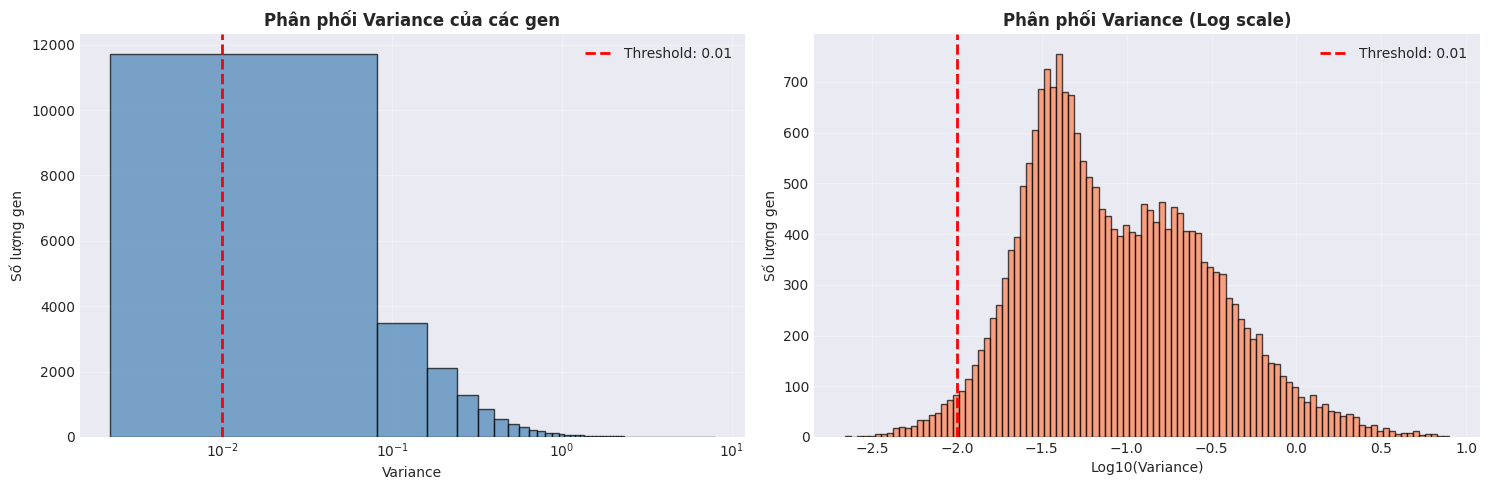


BƯỚC 5: CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)
   - Shape trước standardization: (64, 21769)

   📊 Thống kê TRƯỚC standardization:
   - Mean: 6.5583
   - Std: 1.6970
   - Min: 3.1875
   - Max: 14.4654

   📊 Thống kê SAU standardization:
   - Mean: -0.000000 (≈ 0)
   - Std: 1.000000 (≈ 1)
   - Min: -5.6599
   - Max: 7.7212

   ✓ Đã chuẩn hóa dữ liệu (mean=0, std=1)
   ✓ Shape sau standardization: (64, 21769)


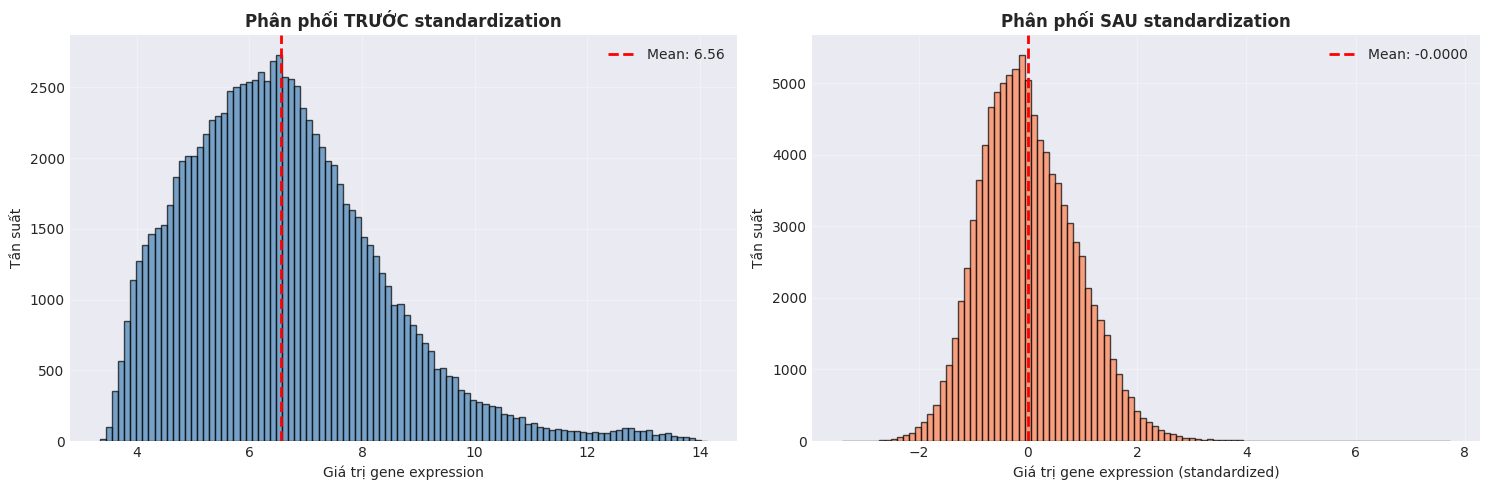


BƯỚC 6: PCA - GIẢM CHIỀU DỮ LIỆU
   - Shape trước PCA: (64, 21769)
   - Số features: 21,769

   ⚠️  Giới hạn: Tối đa 64 components (min của 64 samples và 21769 features)

   📊 Thử nghiệm với nhiều số lượng components:
   - 10 components:  66.18% variance explained
   - 20 components:  79.12% variance explained
   - 30 components:  86.87% variance explained
   - 40 components:  92.25% variance explained
   - 50 components:  96.34% variance explained
   - 60 components:  99.32% variance explained

   📊 PCA với 90% variance explained:
   - Số components cần: 36
   - Explained variance thực tế: 90.32%

   ✓ Đã giảm chiều: (64, 21769) → (64, 36)
   → Giảm 21,733 features (99.83%)
   → Giữ lại 90.32% thông tin


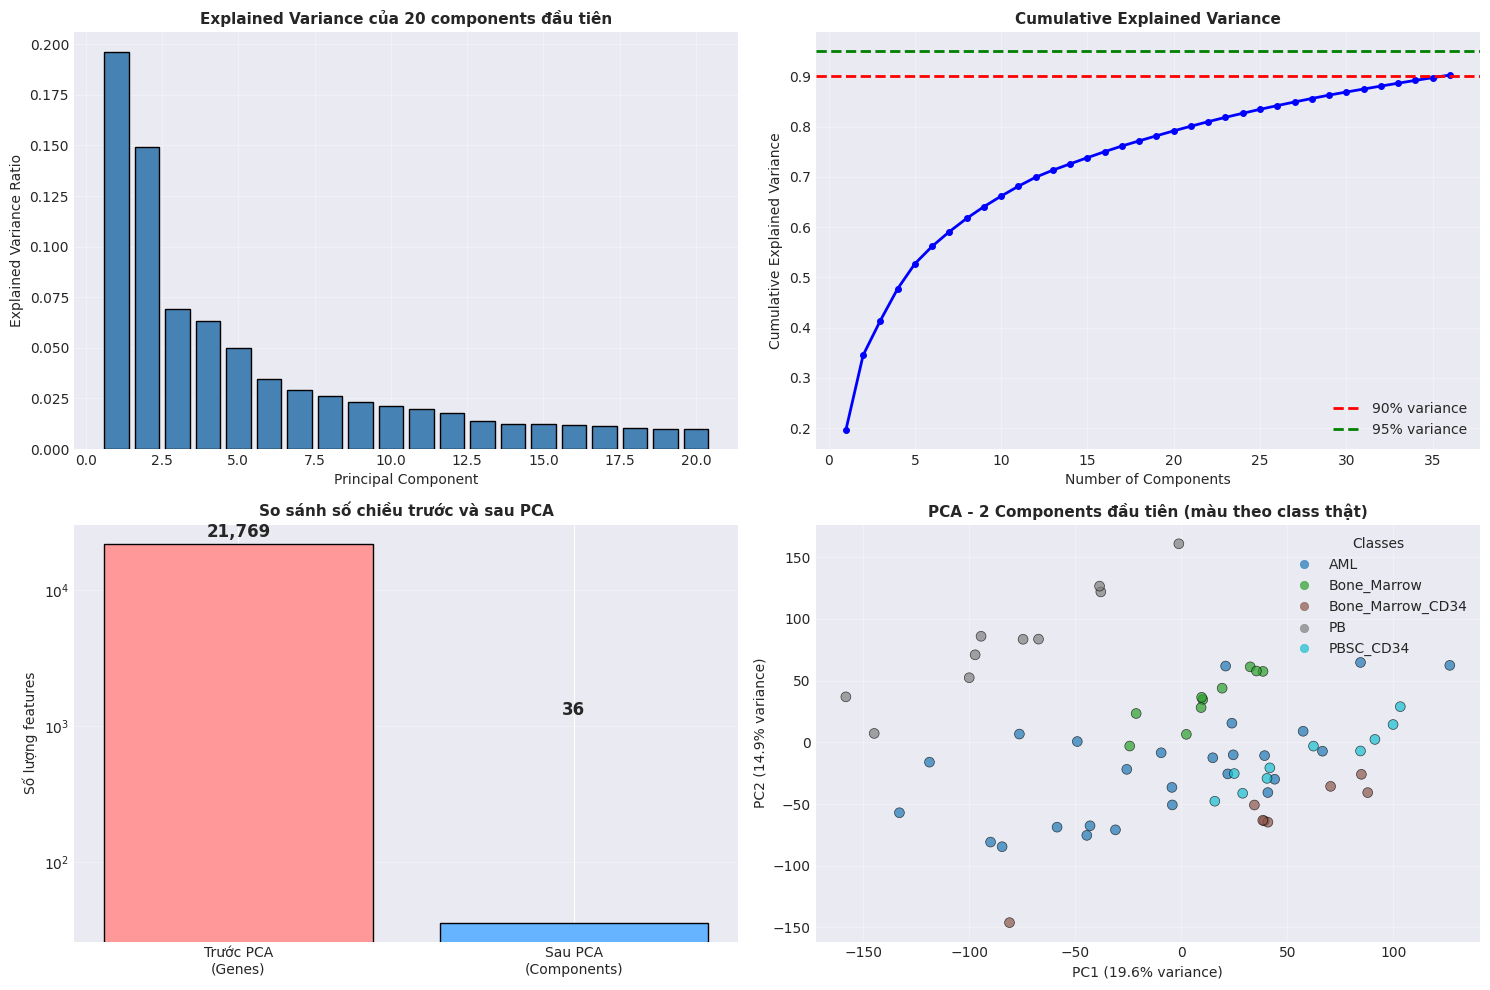


TÓM TẮT KẾT QUẢ CLEAN DATA VÀ PCA

📋 TÓM TẮT QUÁ TRÌNH TIỀN XỬ LÝ:

1. BỎ METADATA:
   - Bỏ 2 cột metadata: ['samples', 'type']
   - Shape: (64, 22285) → (64, 22215)

2. BỎ CONTROL PROBES (AFFX):
   - Bỏ 68 cột AFFX
   - Shape: (64, 22215) → 64 × 22147

3. LOẠI BỎ LOW VARIANCE GENES:
   - Bỏ 446 gen có variance < 0.01
   - Shape: (64, 22215) → (64, 21769)

4. STANDARDIZATION:
   - Chuẩn hóa về mean=0, std=1
   - Shape: (64, 21769) → (64, 21769)

5. PCA:
   - Giảm từ 21,769 features → 36 components
   - Giữ lại 90.32% variance
   - Shape cuối cùng: (64, 36)

✅ DỮ LIỆU SẴN SÀNG CHO CLUSTERING:
   - X_pca: (64, 36) (samples × PCA components)
   - Có thể dùng cho: K-Means, Agglomerative Clustering, Spectral Clustering


KẾT THÚC CLEAN DATA VÀ PCA


In [21]:
# =================================================================================
# CLEAN DATA VÀ PCA - TIỀN XỬ LÝ DỮ LIỆU CHO CLUSTERING
# =================================================================================
# Mục tiêu: Chuẩn bị dữ liệu sạch và giảm chiều trước khi clustering
# Các bước: Bỏ metadata → Bỏ AFFX → Loại bỏ low variance → Standardization → PCA

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

print("=" * 100)
print("CLEAN DATA VÀ PCA - TIỀN XỬ LÝ DỮ LIỆU")
print("=" * 100)

# =================================================================================
# BƯỚC 1: LOAD DATA VÀ LƯU METADATA
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 1: LOAD DATA VÀ LƯU METADATA")
print("=" * 100)

file_path = "./Leukemia.csv"
df = pd.read_csv(file_path)

print(f"\n📥 Original shape: {df.shape}")
print(f"   - {df.shape[0]:,} samples")
print(f"   - {df.shape[1]:,} columns")

# Lưu lại metadata để đánh giá sau
metadata_cols = ['samples', 'type', 'label', 'class', 'Class']
found_metadata = [c for c in metadata_cols if c in df.columns]

if 'type' in df.columns:
    y_true_str = df['type'].copy()
    n_classes_true = y_true_str.nunique()
    print(f"\n📌 Lưu lại metadata:")
    print(f"   - Cột 'type' (nhãn thật): {n_classes_true} classes")
    print(f"   - Các classes: {sorted(y_true_str.unique())}")
else:
    y_true_str = None
    n_classes_true = None

# =================================================================================
# BƯỚC 2: BỎ METADATA COLUMNS
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 2: BỎ METADATA COLUMNS")
print("=" * 100)

df_clean = df.drop(columns=[c for c in metadata_cols if c in df.columns], errors='ignore')
print(f"   ✓ Đã bỏ metadata columns: {found_metadata}")
print(f"   ✓ Shape sau khi bỏ metadata: {df_clean.shape}")
print(f"   → Giảm {df.shape[1] - df_clean.shape[1]} cột")

# =================================================================================
# BƯỚC 3: BỎ CONTROL PROBES (AFFX-*)
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 3: BỎ CONTROL PROBES (AFFX-*)")
print("=" * 100)

affx_cols = [c for c in df_clean.columns if c.startswith("AFFX")]
n_affx = len(affx_cols)
print(f"   - Số cột AFFX tìm thấy: {n_affx:,}")

if n_affx > 0:
    df_clean = df_clean[[c for c in df_clean.columns if not c.startswith("AFFX")]]
    print(f"   ✓ Đã bỏ {n_affx:,} cột AFFX")
    print(f"   ✓ Shape sau khi bỏ AFFX: {df_clean.shape}")
    print(f"   → Giảm {n_affx} cột")
else:
    print(f"   ✓ Không có cột AFFX")

# =================================================================================
# BƯỚC 4: LOẠI BỎ GEN CÓ VARIANCE THẤP
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 4: LOẠI BỎ GEN CÓ VARIANCE THẤP")
print("=" * 100)

# Chuyển sang numpy array
X_temp = df_clean.values.astype(float)
print(f"   - Shape trước khi loại bỏ low variance: {X_temp.shape}")

# Tính variance của từng gen
gene_variances = np.var(X_temp, axis=0)
variance_threshold = 0.01

low_variance_mask = gene_variances < variance_threshold
n_low_variance = np.sum(low_variance_mask)
n_high_variance = len(gene_variances) - n_low_variance

print(f"\n   📊 Phân tích variance:")
print(f"   - Variance threshold: {variance_threshold}")
print(f"   - Variance min: {gene_variances.min():.6f}")
print(f"   - Variance max: {gene_variances.max():.6f}")
print(f"   - Variance mean: {gene_variances.mean():.6f}")
print(f"   - Variance median: {np.median(gene_variances):.6f}")

print(f"\n   📊 Kết quả:")
print(f"   - Gen có variance thấp (< {variance_threshold}): {n_low_variance:,} ({n_low_variance/len(gene_variances)*100:.2f}%)")
print(f"   - Gen có variance cao (≥ {variance_threshold}): {n_high_variance:,} ({n_high_variance/len(gene_variances)*100:.2f}%)")

# Loại bỏ gen có variance thấp
selector = VarianceThreshold(threshold=variance_threshold)
X_clean = selector.fit_transform(X_temp)

print(f"\n   ✓ Đã loại bỏ {n_low_variance:,} gen có variance thấp")
print(f"   ✓ Shape sau khi loại bỏ low variance: {X_clean.shape}")
print(f"   → Giảm {X_temp.shape[1] - X_clean.shape[1]} features")

# Visualization variance
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(gene_variances, bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(variance_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold: {variance_threshold}')
axes[0].set_title('Phân phối Variance của các gen', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Variance', fontsize=10)
axes[0].set_ylabel('Số lượng gen', fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xscale('log')

axes[1].hist(np.log10(gene_variances + 1e-10), bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(np.log10(variance_threshold), color='red', linestyle='--', linewidth=2, label=f'Threshold: {variance_threshold}')
axes[1].set_title('Phân phối Variance (Log scale)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log10(Variance)', fontsize=10)
axes[1].set_ylabel('Số lượng gen', fontsize=10)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# BƯỚC 5: CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 5: CHUẨN HÓA DỮ LIỆU (STANDARDIZATION)")
print("=" * 100)

print(f"   - Shape trước standardization: {X_clean.shape}")

# Kiểm tra scale trước khi chuẩn hóa
print(f"\n   📊 Thống kê TRƯỚC standardization:")
print(f"   - Mean: {np.mean(X_clean):.4f}")
print(f"   - Std: {np.std(X_clean):.4f}")
print(f"   - Min: {np.min(X_clean):.4f}")
print(f"   - Max: {np.max(X_clean):.4f}")

# Chuẩn hóa
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_clean)

print(f"\n   📊 Thống kê SAU standardization:")
print(f"   - Mean: {np.mean(X_scaled):.6f} (≈ 0)")
print(f"   - Std: {np.std(X_scaled):.6f} (≈ 1)")
print(f"   - Min: {np.min(X_scaled):.4f}")
print(f"   - Max: {np.max(X_scaled):.4f}")

print(f"\n   ✓ Đã chuẩn hóa dữ liệu (mean=0, std=1)")
print(f"   ✓ Shape sau standardization: {X_scaled.shape}")

# Visualization trước và sau standardization
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Trước standardization
axes[0].hist(X_clean.flatten()[:100000], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(X_clean), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(X_clean):.2f}')
axes[0].set_title('Phân phối TRƯỚC standardization', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Giá trị gene expression', fontsize=10)
axes[0].set_ylabel('Tần suất', fontsize=10)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Sau standardization
axes[1].hist(X_scaled.flatten()[:100000], bins=100, color='coral', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(X_scaled), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(X_scaled):.4f}')
axes[1].set_title('Phân phối SAU standardization', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Giá trị gene expression (standardized)', fontsize=10)
axes[1].set_ylabel('Tần suất', fontsize=10)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# BƯỚC 6: PCA - GIẢM CHIỀU DỮ LIỆU
# =================================================================================
print("\n" + "=" * 100)
print("BƯỚC 6: PCA - GIẢM CHIỀU DỮ LIỆU")
print("=" * 100)

print(f"   - Shape trước PCA: {X_scaled.shape}")
print(f"   - Số features: {X_scaled.shape[1]:,}")

# Giới hạn số components tối đa
max_components = min(X_scaled.shape[0], X_scaled.shape[1])
print(f"\n   ⚠️  Giới hạn: Tối đa {max_components} components (min của {X_scaled.shape[0]} samples và {X_scaled.shape[1]} features)")

# Thử với nhiều số lượng components để xem explained variance
print(f"\n   📊 Thử nghiệm với nhiều số lượng components:")

n_components_list = [10, 20, 30, 40, 50, 60]
n_components_list = [n for n in n_components_list if n <= max_components]

explained_variances = []
for n_comp in n_components_list:
    pca_temp = PCA(n_components=n_comp)
    pca_temp.fit(X_scaled)
    exp_var = pca_temp.explained_variance_ratio_.sum()
    explained_variances.append(exp_var)
    print(f"   - {n_comp:2d} components: {exp_var*100:6.2f}% variance explained")

# Chọn số components dựa trên explained variance (giữ 90% variance)
target_variance = 0.90
pca_90 = PCA(n_components=target_variance)
pca_90.fit(X_scaled)
n_components_90 = pca_90.n_components_
explained_var_90 = pca_90.explained_variance_ratio_.sum()

print(f"\n   📊 PCA với {target_variance*100:.0f}% variance explained:")
print(f"   - Số components cần: {n_components_90}")
print(f"   - Explained variance thực tế: {explained_var_90*100:.2f}%")

# Áp dụng PCA với số components đã chọn
pca = PCA(n_components=n_components_90, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"\n   ✓ Đã giảm chiều: {X_scaled.shape} → {X_pca.shape}")
print(f"   → Giảm {X_scaled.shape[1] - X_pca.shape[1]:,} features ({((X_scaled.shape[1] - X_pca.shape[1])/X_scaled.shape[1]*100):.2f}%)")
print(f"   → Giữ lại {explained_var_90*100:.2f}% thông tin")

# Visualization PCA
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Explained variance ratio của các components đầu tiên
n_comp_to_plot = min(20, n_components_90)
axes[0, 0].bar(range(1, n_comp_to_plot + 1), pca.explained_variance_ratio_[:n_comp_to_plot], color='steelblue', edgecolor='black')
axes[0, 0].set_title(f'Explained Variance của {n_comp_to_plot} components đầu tiên', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Principal Component', fontsize=10)
axes[0, 0].set_ylabel('Explained Variance Ratio', fontsize=10)
axes[0, 0].grid(alpha=0.3)

# 2. Cumulative explained variance
cumulative_var = np.cumsum(pca.explained_variance_ratio_)
axes[0, 1].plot(range(1, len(cumulative_var) + 1), cumulative_var, 'b-o', markersize=4, linewidth=2)
axes[0, 1].axhline(y=0.90, color='r', linestyle='--', linewidth=2, label='90% variance')
axes[0, 1].axhline(y=0.95, color='g', linestyle='--', linewidth=2, label='95% variance')
axes[0, 1].set_title('Cumulative Explained Variance', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Number of Components', fontsize=10)
axes[0, 1].set_ylabel('Cumulative Explained Variance', fontsize=10)
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. So sánh số chiều trước và sau PCA
dimensions = ['Trước PCA\n(Genes)', 'Sau PCA\n(Components)']
sizes = [X_scaled.shape[1], X_pca.shape[1]]
colors = ['#ff9999', '#66b3ff']
axes[1, 0].bar(dimensions, sizes, color=colors, edgecolor='black')
axes[1, 0].set_title('So sánh số chiều trước và sau PCA', fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel('Số lượng features', fontsize=10)
for i, (dim, size) in enumerate(zip(dimensions, sizes)):
    axes[1, 0].text(i, size + max(sizes)*0.05, f'{size:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1, 0].set_yscale('log')
axes[1, 0].grid(alpha=0.3, axis='y')

# 4. Scatter plot của 2 components đầu tiên (nếu có nhãn)
if y_true_str is not None:
    scatter = axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y_true_str).codes, 
                                 cmap='tab10', alpha=0.7, s=50, edgecolors='black', linewidth=0.5)
    axes[1, 1].set_title('PCA - 2 Components đầu tiên (màu theo class thật)', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1, 1].grid(alpha=0.3)
    # Legend
    handles, labels = scatter.legend_elements()
    axes[1, 1].legend(handles, sorted(y_true_str.unique()), title="Classes", loc='best')
else:
    axes[1, 1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=50, color='steelblue', edgecolors='black', linewidth=0.5)
    axes[1, 1].set_title('PCA - 2 Components đầu tiên', fontsize=11, fontweight='bold')
    axes[1, 1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1, 1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# TÓM TẮT KẾT QUẢ
# =================================================================================
print("\n" + "=" * 100)
print("TÓM TẮT KẾT QUẢ CLEAN DATA VÀ PCA")
print("=" * 100)

print(f"""
📋 TÓM TẮT QUÁ TRÌNH TIỀN XỬ LÝ:

1. BỎ METADATA:
   - Bỏ {len(found_metadata)} cột metadata: {found_metadata}
   - Shape: {df.shape} → {df_clean.shape}

2. BỎ CONTROL PROBES (AFFX):
   - Bỏ {n_affx:,} cột AFFX
   - Shape: {df_clean.shape} → {df_clean.shape[0]} × {df_clean.shape[1] - n_affx}

3. LOẠI BỎ LOW VARIANCE GENES:
   - Bỏ {n_low_variance:,} gen có variance < {variance_threshold}
   - Shape: {X_temp.shape} → {X_clean.shape}

4. STANDARDIZATION:
   - Chuẩn hóa về mean=0, std=1
   - Shape: {X_clean.shape} → {X_scaled.shape}

5. PCA:
   - Giảm từ {X_scaled.shape[1]:,} features → {X_pca.shape[1]} components
   - Giữ lại {explained_var_90*100:.2f}% variance
   - Shape cuối cùng: {X_pca.shape}

✅ DỮ LIỆU SẴN SÀNG CHO CLUSTERING:
   - X_pca: {X_pca.shape} (samples × PCA components)
   - Có thể dùng cho: K-Means, Agglomerative Clustering, Spectral Clustering
""")

print("\n" + "=" * 100)
print("KẾT THÚC CLEAN DATA VÀ PCA")
print("=" * 100)


AGGLOMERATIVE CLUSTERING - PHÂN CỤM PHÂN CẤP

📊 CHUẨN BỊ DỮ LIỆU:
   - Sử dụng X_pca từ bước clean data và PCA
   - Shape của X_pca: (64, 36)
   - Số samples: 64
   - Số features (PCA components): 36
   - Labels: ['Sample_1', 'Sample_2', 'Sample_3', 'Sample_4', 'Sample_5']... (tổng 64 samples)

ĐỊNH NGHĨA CÁC HÀM

CHỌN SỐ CLUSTERS (K)
   - Dataset có 5 classes thật
   - Chọn K = 5 (số classes thật)

   ✓ Sẽ chạy Agglomerative Clustering với K = 5

CHẠY AGGLOMERATIVE CLUSTERING

🚀 BẮT ĐẦU CLUSTERING:
   - Số clusters ban đầu: 64
   - Mục tiêu: Giảm xuống còn K = 5 clusters

--- STEP 1 ---
   Hiện tại có 64 clusters

   🔍 Đang tính khoảng cách giữa các cặp clusters...
   Distance between [0] and [1] = 122.9611
   Distance between [0] and [2] = 81.8438
   Distance between [0] and [3] = 141.8800
   Distance between [0] and [4] = 109.5080
   Distance between [0] and [5] = 111.0734
   Distance between [0] and [6] = 240.5643
   Distance between [0] and [7] = 108.3159
   Distance between [0] a

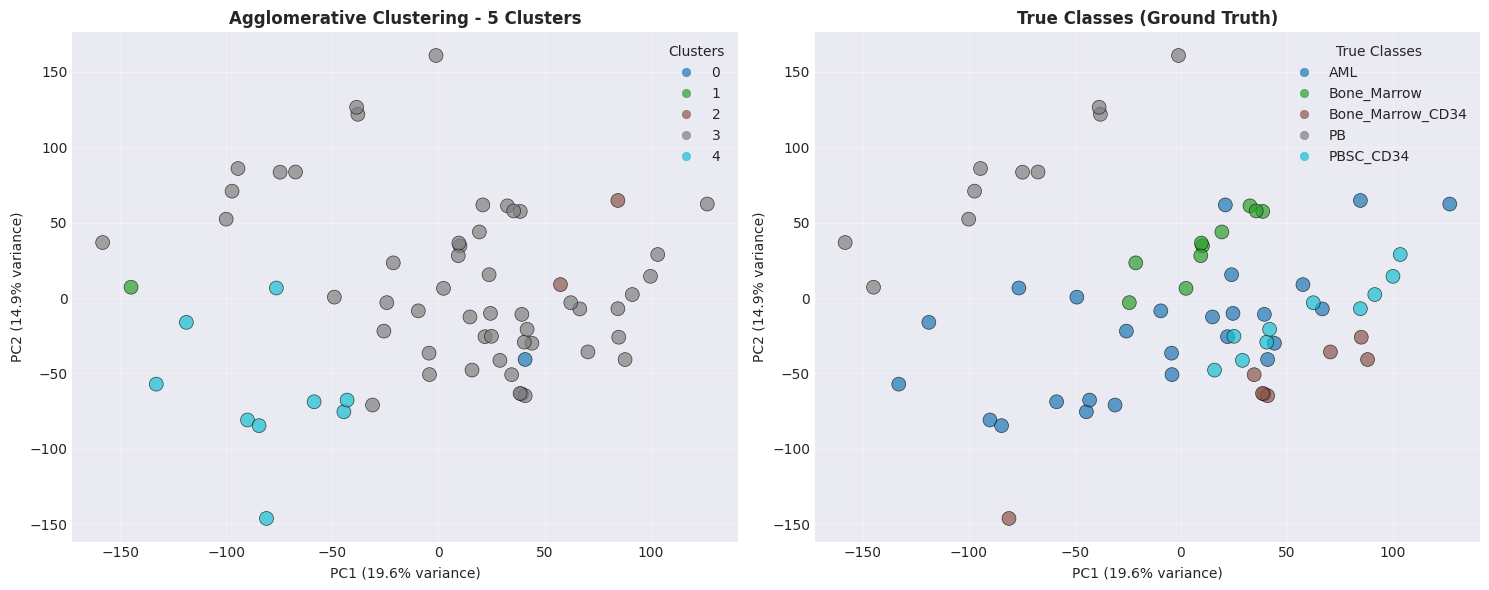


ĐÁNH GIÁ KẾT QUẢ SO VỚI NHÃN THẬT

📊 Metrics đánh giá:
   - ARI (Adjusted Rand Index): -0.0628
     → ARI = 1.0: Hoàn toàn khớp với nhãn thật
     → ARI = 0.0: Không khớp hơn random
   - NMI (Normalized Mutual Information): 0.1733
     → NMI = 1.0: Hoàn toàn khớp với nhãn thật
     → NMI = 0.0: Không có thông tin chung

📊 Confusion Matrix (Clusters vs True Classes):
                        Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5
True: AML                       1          0          2         15          8
True: Bone_Marrow               0          0          0         10          0
True: Bone_Marrow_CD34          0          0          0          7          1
True: PB                        0          1          0          9          0
True: PBSC_CD34                 0          0          0         10          0

📊 Phân tích chi tiết từng cluster:

   Cluster 1 (1 samples):
     • AML: 1 samples (100.0%)

   Cluster 2 (1 samples):
     • PB: 1 samples (100.0%)

   Cluster

In [22]:
# =================================================================================
# AGGLOMERATIVE CLUSTERING - PHÂN CỤM PHÂN CẤP
# =================================================================================
# Giữ nguyên pattern code mẫu đơn giản, dễ hiểu
# Áp dụng với dữ liệu thật (X_pca từ bước clean data và PCA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 100)
print("AGGLOMERATIVE CLUSTERING - PHÂN CỤM PHÂN CẤP")
print("=" * 100)

# =================================================================================
# CHUẨN BỊ DỮ LIỆU
# =================================================================================
print("\n📊 CHUẨN BỊ DỮ LIỆU:")
print("   - Sử dụng X_pca từ bước clean data và PCA")
print(f"   - Shape của X_pca: {X_pca.shape}")
print(f"   - Số samples: {X_pca.shape[0]}")
print(f"   - Số features (PCA components): {X_pca.shape[1]}")

# Tạo labels cho các samples
labels = [f"Sample_{i+1}" for i in range(X_pca.shape[0])]
print(f"   - Labels: {labels[:5]}... (tổng {len(labels)} samples)")

# =================================================================================
# ĐỊNH NGHĨA CÁC HÀM (GIỮ NGUYÊN PATTERN CODE MẪU)
# =================================================================================
print("\n" + "=" * 100)
print("ĐỊNH NGHĨA CÁC HÀM")
print("=" * 100)

def euclidean_distance(x, y):
    """
    Tính khoảng cách Euclidean giữa 2 điểm
    """
    return np.sqrt(np.sum((x - y) ** 2))

def average_linkage(cluster1, cluster2, X):
    """
    Tính khoảng cách trung bình giữa 2 clusters (Average Linkage)
    - Tính khoảng cách giữa TẤT CẢ các cặp điểm (1 điểm từ cluster1, 1 điểm từ cluster2)
    - Lấy trung bình của tất cả các khoảng cách đó
    """
    distances = []
    for i in cluster1:
        for j in cluster2:
            d = euclidean_distance(X[i], X[j])
            distances.append(d)
    return np.mean(distances)

def agglomerative_clustering(X, K=2):
    """
    Thuật toán Agglomerative Clustering (Bottom-up)
    
    Cách hoạt động:
    1. Bắt đầu: Mỗi điểm là 1 cluster riêng biệt
    2. Lặp lại cho đến khi còn K clusters:
       - Tìm 2 clusters gần nhau nhất (dùng average linkage)
       - Gộp 2 clusters đó lại thành 1 cluster mới
    3. Trả về K clusters cuối cùng
    """
    # Bước 1: Mỗi điểm ban đầu là 1 cluster
    clusters = [[i] for i in range(len(X))]
    step = 1

    print(f"\n🚀 BẮT ĐẦU CLUSTERING:")
    print(f"   - Số clusters ban đầu: {len(clusters)}")
    print(f"   - Mục tiêu: Giảm xuống còn K = {K} clusters")

    while len(clusters) > K:
        print(f"\n{'='*80}")
        print(f"--- STEP {step} ---")
        print(f"{'='*80}")
        print(f"   Hiện tại có {len(clusters)} clusters")
        
        min_dist = float("inf")
        pair_to_merge = None

        # Tìm 2 cluster gần nhau nhất
        print(f"\n   🔍 Đang tính khoảng cách giữa các cặp clusters...")
        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = average_linkage(clusters[i], clusters[j], X)
                print(
                    f"   Distance between {clusters[i]} and {clusters[j]} = {dist:.4f}"
                )

                if dist < min_dist:
                    min_dist = dist
                    pair_to_merge = (i, j)

        i, j = pair_to_merge
        print(
            f"\n   👉 Merge clusters {clusters[i]} and {clusters[j]} "
            f"(distance = {min_dist:.4f})"
        )

        # Gộp 2 clusters lại
        new_cluster = clusters[i] + clusters[j]

        # Xóa 2 clusters cũ (xóa j trước vì j > i)
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)

        print(f"   ✓ Clusters sau khi merge: {clusters}")
        print(f"   ✓ Số clusters còn lại: {len(clusters)}")
        step += 1

    return clusters

# =================================================================================
# CHỌN SỐ CLUSTERS (K)
# =================================================================================
print("\n" + "=" * 100)
print("CHỌN SỐ CLUSTERS (K)")
print("=" * 100)

# Sử dụng số classes thật nếu có
if 'n_classes_true' in globals() and n_classes_true is not None:
    K_selected = n_classes_true
    print(f"   - Dataset có {n_classes_true} classes thật")
    print(f"   - Chọn K = {K_selected} (số classes thật)")
else:
    K_selected = 5  # Mặc định
    print(f"   - Không có thông tin về số classes thật")
    print(f"   - Chọn K = {K_selected} (mặc định)")

print(f"\n   ✓ Sẽ chạy Agglomerative Clustering với K = {K_selected}")

# =================================================================================
# CHẠY CLUSTERING
# =================================================================================
print("\n" + "=" * 100)
print("CHẠY AGGLOMERATIVE CLUSTERING")
print("=" * 100)

final_clusters = agglomerative_clustering(X_pca, K=K_selected)

# =================================================================================
# HIỂN THỊ KẾT QUẢ
# =================================================================================
print("\n" + "=" * 100)
print("KẾT QUẢ CLUSTERING")
print("=" * 100)

print(f"\n📊 FINAL CLUSTERS (K = {K_selected}):")
for idx, cluster in enumerate(final_clusters):
    print(f"\n   Cluster {idx + 1}:")
    print(f"   - Số samples: {len(cluster)}")
    print(f"   - Indices: {cluster}")
    print(f"   - Labels: {[labels[i] for i in cluster]}")

# Tạo nhãn dự đoán cho đánh giá
cluster_labels_pred = np.zeros(X_pca.shape[0], dtype=int)
for idx, cluster in enumerate(final_clusters):
    cluster_labels_pred[cluster] = idx

# =================================================================================
# VISUALIZATION
# =================================================================================
print("\n" + "=" * 100)
print("VISUALIZATION KẾT QUẢ")
print("=" * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter plot với màu theo clusters dự đoán
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_pred, 
                          cmap='tab10', alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
axes[0].set_title(f'Agglomerative Clustering - {K_selected} Clusters', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend(*scatter1.legend_elements(), title="Clusters", loc='best')

# 2. Scatter plot với màu theo classes thật (nếu có)
if 'y_true_str' in globals() and y_true_str is not None:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y_true_str).codes, 
                              cmap='tab10', alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
    axes[1].set_title('True Classes (Ground Truth)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1].grid(alpha=0.3)
    handles, labels_legend = scatter2.legend_elements()
    axes[1].legend(handles, sorted(y_true_str.unique()), title="True Classes", loc='best')
else:
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=100, color='steelblue', 
                   edgecolors='black', linewidth=0.5)
    axes[1].set_title('PCA - 2 Components đầu tiên', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# ĐÁNH GIÁ KẾT QUẢ (NẾU CÓ NHÃN THẬT)
# =================================================================================
if 'y_true_str' in globals() and y_true_str is not None:
    print("\n" + "=" * 100)
    print("ĐÁNH GIÁ KẾT QUẢ SO VỚI NHÃN THẬT")
    print("=" * 100)
    
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
    from sklearn.preprocessing import LabelEncoder
    
    # Mã hóa nhãn thật
    le = LabelEncoder()
    y_true_encoded = le.fit_transform(y_true_str)
    
    # Tính metrics
    ari = adjusted_rand_score(y_true_encoded, cluster_labels_pred)
    nmi = normalized_mutual_info_score(y_true_encoded, cluster_labels_pred)
    
    print(f"\n📊 Metrics đánh giá:")
    print(f"   - ARI (Adjusted Rand Index): {ari:.4f}")
    print(f"     → ARI = 1.0: Hoàn toàn khớp với nhãn thật")
    print(f"     → ARI = 0.0: Không khớp hơn random")
    print(f"   - NMI (Normalized Mutual Information): {nmi:.4f}")
    print(f"     → NMI = 1.0: Hoàn toàn khớp với nhãn thật")
    print(f"     → NMI = 0.0: Không có thông tin chung")
    
    # Confusion Matrix
    print(f"\n📊 Confusion Matrix (Clusters vs True Classes):")
    cm = confusion_matrix(y_true_encoded, cluster_labels_pred)
    cm_df = pd.DataFrame(cm, 
                         index=[f"True: {label}" for label in le.classes_],
                         columns=[f"Cluster {i+1}" for i in range(len(final_clusters))])
    print(cm_df.to_string())
    
    # Phân tích từng cluster
    print(f"\n📊 Phân tích chi tiết từng cluster:")
    for idx, cluster in enumerate(final_clusters):
        cluster_labels = [y_true_str.iloc[i] for i in cluster]
        from collections import Counter
        label_counts = Counter(cluster_labels)
        print(f"\n   Cluster {idx+1} ({len(cluster)} samples):")
        for label, count in label_counts.items():
            percentage = (count / len(cluster)) * 100
            print(f"     • {label}: {count} samples ({percentage:.1f}%)")

print("\n" + "=" * 100)
print("KẾT THÚC AGGLOMERATIVE CLUSTERING")
print("=" * 100)


In [ ]:
# =================================================================================
# K-MEANS CLUSTERING - PHÂN CỤM K-MEANS
# =================================================================================
# Giữ nguyên pattern code mẫu đơn giản, dễ hiểu
# Áp dụng với dữ liệu thật (X_pca từ bước clean data và PCA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 100)
print("K-MEANS CLUSTERING - PHÂN CỤM K-MEANS")
print("=" * 100)

# =================================================================================
# CHUẨN BỊ DỮ LIỆU
# =================================================================================
print("\n📊 CHUẨN BỊ DỮ LIỆU:")
print("   - Sử dụng X_pca từ bước clean data và PCA")
print(f"   - Shape của X_pca: {X_pca.shape}")
print(f"   - Số samples: {X_pca.shape[0]}")
print(f"   - Số features (PCA components): {X_pca.shape[1]}")

# Tạo labels cho các samples
labels = [f"Sample_{i+1}" for i in range(X_pca.shape[0])]
print(f"   - Labels: {labels[:5]}... (tổng {len(labels)} samples)")

# =================================================================================
# ĐỊNH NGHĨA CÁC HÀM (GIỮ NGUYÊN PATTERN CODE MẪU)
# =================================================================================
print("\n" + "=" * 100)
print("ĐỊNH NGHĨA CÁC HÀM")
print("=" * 100)

def euclidean_distance(x, y):
    """
    Tính khoảng cách Euclidean giữa 2 điểm
    """
    return np.sqrt(np.sum((x - y) ** 2))

def initialize_centroids(X, K, random_state=None):
    """
    Khởi tạo K centroids ngẫu nhiên
    - Chọn K điểm ngẫu nhiên từ dataset làm centroids ban đầu
    """
    if random_state is not None:
        np.random.seed(random_state)
    
    # Chọn K indices ngẫu nhiên
    n_samples = X.shape[0]
    random_indices = np.random.choice(n_samples, size=K, replace=False)
    centroids = X[random_indices].copy()
    
    return centroids

def assign_clusters(X, centroids):
    """
    Gán mỗi điểm vào cluster gần nhất
    - Tính khoảng cách từ mỗi điểm đến tất cả centroids
    - Gán điểm vào cluster có centroid gần nhất
    """
    n_samples = X.shape[0]
    n_clusters = len(centroids)
    labels = np.zeros(n_samples, dtype=int)
    
    for i in range(n_samples):
        distances = []
        for k in range(n_clusters):
            dist = euclidean_distance(X[i], centroids[k])
            distances.append(dist)
        labels[i] = np.argmin(distances)
    
    return labels

def update_centroids(X, labels, K):
    """
    Cập nhật centroids: Tính trung bình của tất cả điểm trong mỗi cluster
    - Với mỗi cluster, tính mean của tất cả điểm thuộc cluster đó
    - Mean đó trở thành centroid mới
    """
    n_features = X.shape[1]
    centroids = np.zeros((K, n_features))
    
    for k in range(K):
        # Lấy tất cả điểm thuộc cluster k
        cluster_points = X[labels == k]
        
        if len(cluster_points) > 0:
            # Tính trung bình (mean) của các điểm trong cluster
            centroids[k] = np.mean(cluster_points, axis=0)
        else:
            # Nếu cluster rỗng, giữ nguyên centroid cũ (hoặc random)
            # Ở đây ta sẽ giữ nguyên để tránh lỗi
            pass
    
    return centroids

def kmeans_clustering(X, K=2, max_iters=100, random_state=None, verbose=True):
    """
    Thuật toán K-Means Clustering
    
    Cách hoạt động:
    1. Khởi tạo: Chọn K điểm ngẫu nhiên làm centroids ban đầu
    2. Lặp lại cho đến khi hội tụ hoặc đạt max_iters:
       a. Gán cụm: Gán mỗi điểm vào cluster có centroid gần nhất
       b. Cập nhật: Tính lại centroids = mean của các điểm trong cluster
       c. Kiểm tra: Nếu centroids không đổi → hội tụ → dừng
    3. Trả về labels (nhãn cluster) và centroids cuối cùng
    """
    if verbose:
        print(f"\n🚀 BẮT ĐẦU K-MEANS CLUSTERING:")
        print(f"   - Số clusters (K): {K}")
        print(f"   - Số samples: {X.shape[0]}")
        print(f"   - Số features: {X.shape[1]}")
        print(f"   - Max iterations: {max_iters}")
    
    # Bước 1: Khởi tạo centroids
    centroids = initialize_centroids(X, K, random_state=random_state)
    
    if verbose:
        print(f"\n   ✓ Đã khởi tạo {K} centroids ngẫu nhiên")
        print(f"   - Centroids ban đầu:")
        for k in range(K):
            print(f"     Centroid {k+1}: {centroids[k]}")
    
    # Lặp lại cho đến khi hội tụ
    for iteration in range(max_iters):
        if verbose:
            print(f"\n{'='*80}")
            print(f"--- ITERATION {iteration + 1} ---")
            print(f"{'='*80}")
        
        # Lưu centroids cũ để so sánh
        old_centroids = centroids.copy()
        
        # Bước 2a: Gán cụm - Gán mỗi điểm vào cluster gần nhất
        labels = assign_clusters(X, centroids)
        
        if verbose:
            # Đếm số điểm trong mỗi cluster
            cluster_counts = [np.sum(labels == k) for k in range(K)]
            print(f"\n   📊 Gán cụm (Assignment):")
            for k in range(K):
                print(f"     Cluster {k+1}: {cluster_counts[k]} points")
        
        # Bước 2b: Cập nhật centroids
        centroids = update_centroids(X, labels, K)
        
        if verbose:
            print(f"\n   📊 Cập nhật centroids:")
            for k in range(K):
                print(f"     Centroid {k+1}: {centroids[k]}")
        
        # Bước 2c: Kiểm tra hội tụ
        # Nếu centroids không thay đổi (hoặc thay đổi rất ít) → hội tụ
        centroids_changed = np.sum(np.abs(centroids - old_centroids))
        
        if verbose:
            print(f"\n   📊 Kiểm tra hội tụ:")
            print(f"     - Độ thay đổi centroids: {centroids_changed:.6f}")
        
        if centroids_changed < 1e-6:  # Hội tụ nếu thay đổi < 0.000001
            if verbose:
                print(f"     ✓ HỘI TỤ! Centroids không thay đổi nữa.")
                print(f"     ✓ Dừng sau {iteration + 1} iterations")
            break
        
        if verbose:
            print(f"     → Tiếp tục iteration tiếp theo...")
    
    if verbose and iteration == max_iters - 1:
        print(f"\n   ⚠️  Đạt max_iters ({max_iters}) - Dừng iteration")
    
    return labels, centroids

# =================================================================================
# CHỌN SỐ CLUSTERS (K)
# =================================================================================
print("\n" + "=" * 100)
print("CHỌN SỐ CLUSTERS (K)")
print("=" * 100)

# Sử dụng số classes thật nếu có
if 'n_classes_true' in globals() and n_classes_true is not None:
    K_selected = n_classes_true
    print(f"   - Dataset có {n_classes_true} classes thật")
    print(f"   - Chọn K = {K_selected} (số classes thật)")
else:
    K_selected = 5  # Mặc định
    print(f"   - Không có thông tin về số classes thật")
    print(f"   - Chọn K = {K_selected} (mặc định)")

print(f"\n   ✓ Sẽ chạy K-Means với K = {K_selected}")

# =================================================================================
# CHẠY CLUSTERING
# =================================================================================
print("\n" + "=" * 100)
print("CHẠY K-MEANS CLUSTERING")
print("=" * 100)

# Chạy K-Means
cluster_labels_kmeans, centroids_final = kmeans_clustering(
    X_pca, 
    K=K_selected, 
    max_iters=100, 
    random_state=42,
    verbose=True
)

# =================================================================================
# HIỂN THỊ KẾT QUẢ
# =================================================================================
print("\n" + "=" * 100)
print("KẾT QUẢ CLUSTERING")
print("=" * 100)

print(f"\n📊 FINAL CLUSTERS (K = {K_selected}):")
for k in range(K_selected):
    cluster_indices = np.where(cluster_labels_kmeans == k)[0]
    print(f"\n   Cluster {k + 1}:")
    print(f"   - Số samples: {len(cluster_indices)}")
    print(f"   - Indices: {list(cluster_indices)}")
    print(f"   - Labels: {[labels[i] for i in cluster_indices]}")
    print(f"   - Centroid: {centroids_final[k]}")

# =================================================================================
# VISUALIZATION
# =================================================================================
print("\n" + "=" * 100)
print("VISUALIZATION KẾT QUẢ")
print("=" * 100)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Scatter plot với màu theo clusters dự đoán + centroids
scatter1 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels_kmeans, 
                          cmap='tab10', alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
# Vẽ centroids
axes[0].scatter(centroids_final[:, 0], centroids_final[:, 1], 
               c='red', marker='X', s=300, edgecolors='black', linewidth=2, 
               label='Centroids', zorder=10)
axes[0].set_title(f'K-Means Clustering - {K_selected} Clusters', fontsize=12, fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].legend()

# 2. Scatter plot với màu theo classes thật (nếu có)
if 'y_true_str' in globals() and y_true_str is not None:
    scatter2 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=pd.Categorical(y_true_str).codes, 
                              cmap='tab10', alpha=0.7, s=100, edgecolors='black', linewidth=0.5)
    axes[1].set_title('True Classes (Ground Truth)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1].grid(alpha=0.3)
    handles, labels_legend = scatter2.legend_elements()
    axes[1].legend(handles, sorted(y_true_str.unique()), title="True Classes", loc='best')
else:
    axes[1].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, s=100, color='steelblue', 
                   edgecolors='black', linewidth=0.5)
    axes[1].set_title('PCA - 2 Components đầu tiên', fontsize=12, fontweight='bold')
    axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
    axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
    axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =================================================================================
# ĐÁNH GIÁ KẾT QUẢ (NẾU CÓ NHÃN THẬT)
# =================================================================================
if 'y_true_str' in globals() and y_true_str is not None:
    print("\n" + "=" * 100)
    print("ĐÁNH GIÁ KẾT QUẢ SO VỚI NHÃN THẬT")
    print("=" * 100)
    
    from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, confusion_matrix
    from sklearn.preprocessing import LabelEncoder
    
    # Mã hóa nhãn thật
    le = LabelEncoder()
    y_true_encoded = le.fit_transform(y_true_str)
    
    # Tính metrics
    ari = adjusted_rand_score(y_true_encoded, cluster_labels_kmeans)
    nmi = normalized_mutual_info_score(y_true_encoded, cluster_labels_kmeans)
    
    print(f"\n📊 Metrics đánh giá:")
    print(f"   - ARI (Adjusted Rand Index): {ari:.4f}")
    print(f"     → ARI = 1.0: Hoàn toàn khớp với nhãn thật")
    print(f"     → ARI = 0.0: Không khớp hơn random")
    print(f"   - NMI (Normalized Mutual Information): {nmi:.4f}")
    print(f"     → NMI = 1.0: Hoàn toàn khớp với nhãn thật")
    print(f"     → NMI = 0.0: Không có thông tin chung")
    
    # Confusion Matrix
    print(f"\n📊 Confusion Matrix (Clusters vs True Classes):")
    cm = confusion_matrix(y_true_encoded, cluster_labels_kmeans)
    cm_df = pd.DataFrame(cm, 
                         index=[f"True: {label}" for label in le.classes_],
                         columns=[f"Cluster {i+1}" for i in range(K_selected)])
    print(cm_df.to_string())
    
    # Phân tích từng cluster
    print(f"\n📊 Phân tích chi tiết từng cluster:")
    for k in range(K_selected):
        cluster_indices = np.where(cluster_labels_kmeans == k)[0]
        cluster_labels = [y_true_str.iloc[i] for i in cluster_indices]
        from collections import Counter
        label_counts = Counter(cluster_labels)
        print(f"\n   Cluster {k+1} ({len(cluster_indices)} samples):")
        for label, count in label_counts.items():
            percentage = (count / len(cluster_indices)) * 100
            print(f"     • {label}: {count} samples ({percentage:.1f}%)")

print("\n" + "=" * 100)
print("KẾT THÚC K-MEANS CLUSTERING")
print("=" * 100)


# K- mean

--- Đang tải và tiền xử lý dữ liệu ---
Columns in DataFrame after reading CSV: Index(['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at',
       '1255_g_at', '1294_at', '1316_at', '1320_at',
       ...
       'AFFX-r2-Hs28SrRNA-5_at', 'AFFX-r2-Hs28SrRNA-M_at',
       'AFFX-r2-P1-cre-3_at', 'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at',
       'AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at',
       'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at'],
      dtype='object', length=22285)
--- Đang chạy Ensemble với K-Means tự viết (50 lần) ---

KẾT QUẢ PHÂN CỤM:
- Chỉ số ARI (Khớp nhãn): 0.3272
- Chỉ số NMI (Độ tinh khiết thông tin): 0.6043


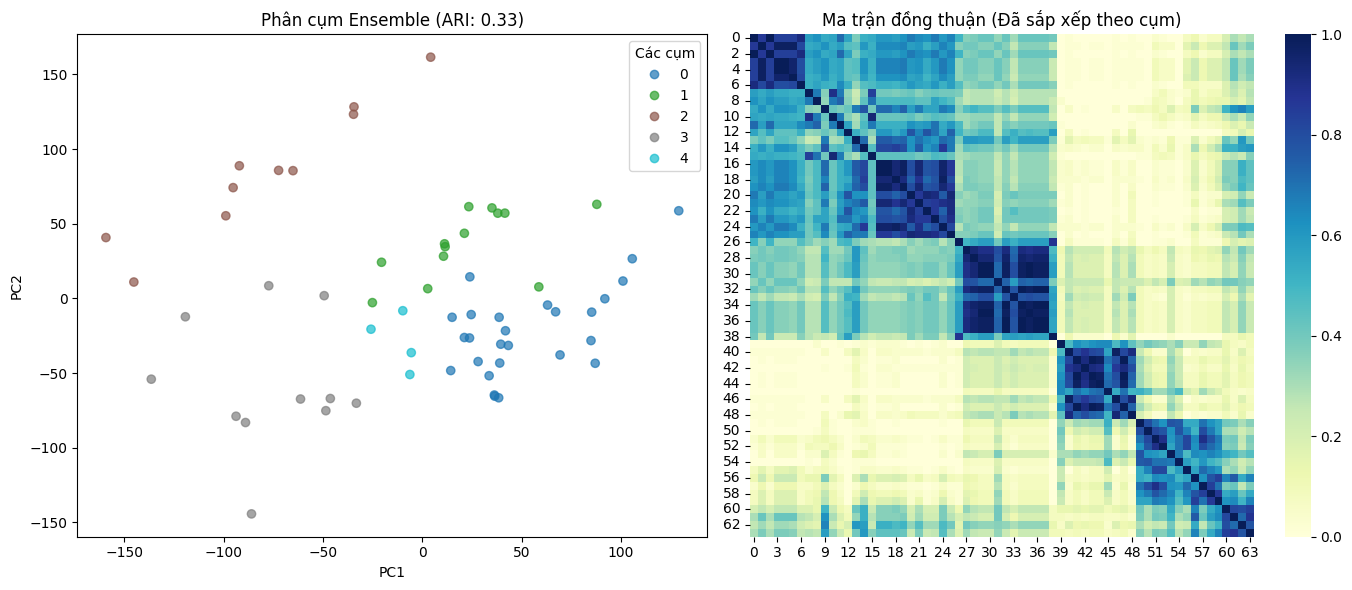


Đã lưu toàn bộ kết quả vào file 'ket_qua_tong_hop.csv'


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
import os # Import the os module

# =================================================================
# BƯỚC 1: ĐỊNH NGHĨA THUẬT TOÁN K-MEANS (VIẾT TAY)
# =================================================================
class KMeansTuViet:
    """
    Cách K-Means vận hành:
    1. Khởi tạo: Chọn ngẫu nhiên K điểm làm tâm cụm (centroids).
    2. Gán cụm: Tính khoảng cách Euclidean từ mỗi mẫu đến các tâm, gán mẫu vào tâm gần nhất.
    3. Cập nhật: Tính trung bình cộng các mẫu trong cụm để tìm tâm mới.
    4. Lặp lại cho đến khi tâm không thay đổi hoặc đạt số lần lặp tối đa.
    """
    def __init__(self, n_clusters=5, max_iters=100, random_state=None):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.random_state = random_state
        self.centroids = None

    def fit_predict(self, X):
        if self.random_state is not None:
            np.random.seed(self.random_state)

        # 1. Khởi tạo tâm cụm ngẫu nhiên
        ngau_nhien_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[ngau_nhien_idx]

        for i in range(self.max_iters):
            # 2. Bước gán cụm (Tính khoảng cách Euclidean)
            # distances[i, j] là khoảng cách từ mẫu i đến tâm cụm j
            khoang_cach = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            nhan_tam_thoi = np.argmin(khoang_cach, axis=1)

            # 3. Bước cập nhật tâm cụm (Tính trung bình cộng)
            cac_tam_moi = []
            for k in range(self.n_clusters):
                cac_diem_trong_cum = X[nhan_tam_thoi == k]
                if len(cac_diem_trong_cum) > 0:
                    cac_tam_moi.append(cac_diem_trong_cum.mean(axis=0))
                else:
                    # Nếu cụm trống, giữ nguyên tâm cũ
                    cac_tam_moi.append(self.centroids[k])

            cac_tam_moi = np.array(cac_tam_moi)

            # Kiểm tra hội tụ (nếu tâm không đổi thì dừng)
            if np.allclose(self.centroids, cac_tam_moi):
                break
            self.centroids = cac_tam_moi

        return nhan_tam_thoi

# =================================================================
# BƯỚC 2: TẢI VÀ TIỀN XỬ LÝ DỮ LIỆU (MACHINE LEARNING)
# =================================================================
print("--- Đang tải và tiền xử lý dữ liệu ---")

file_name = 'Leukemia.csv'
if not os.path.exists(file_name):
    print(f"Lỗi: Không tìm thấy file '{file_name}'. Vui lòng tải file lên lại hoặc kiểm tra đường dẫn.")
    raise FileNotFoundError(f"File '{file_name}' không tồn tại. Vui lòng tải lên file Leukemia.csv vào môi trường Colab.")

df = pd.read_csv(file_name)
print("Columns in DataFrame after reading CSV:", df.columns) # Added for debugging
X_raw = df.drop(columns=['samples', 'type']).values
y_true_str = df['type']

# Mã hóa nhãn thực tế để đối chiếu
le = LabelEncoder()
y_true = le.fit_transform(y_true_str)

# Chuẩn hóa dữ liệu (Z-score) - Quan trọng cho K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Giảm chiều PCA (Giảm từ 22k gen xuống 50 thành phần chính để lọc nhiễu)
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

# =================================================================
# BƯỚC 3: SƠ ĐỒ ASSEMBLE (ENSEMBLE CLUSTERING)
# =================================================================
n_samples = X_pca.shape[0]
n_clusters = 5
n_iterations = 50 # Chạy K-Means 50 lần để lấy kết quả ổn định nhất
ma_tran_dong_thuan = np.zeros((n_samples, n_samples))

print(f"--- Đang chạy Ensemble với K-Means tự viết ({n_iterations} lần) ---")

for i in range(n_iterations):
    # ÁP DỤNG K-MEANS TỰ VIẾT
    km = KMeansTuViet(n_clusters=n_clusters, random_state=i)
    labels = km.fit_predict(X_pca)

    # Cập nhật Ma trận đồng thuận: C_ij = 1 nếu mẫu i và j cùng cụm
    ma_tran_cum = labels[:, np.newaxis] == labels
    ma_tran_dong_thuan += ma_tran_cum

# Chia trung bình để lấy xác suất đồng thuận
ma_tran_dong_thuan /= n_iterations

# =================================================================
# BƯỚC 4: KẾT QUẢ CUỐI CÙNG VÀ ĐÁNH GIÁ
# =================================================================
# Chuyển đổi sang ma trận khoảng cách
ma_tran_khoang_cach = 1 - ma_tran_dong_thuan

# Phân cụm phân cấp để chốt kết quả dựa trên sự đồng thuận
model_cuoi = AgglomerativeClustering(n_clusters=n_clusters, metric='precomputed', linkage='average')
y_du_doan = model_cuoi.fit_predict(ma_tran_khoang_cach)

# Đánh giá bằng ARI và NMI
ari = adjusted_rand_score(y_true, y_du_doan)
nmi = normalized_mutual_info_score(y_true, y_du_doan)

print(f"\nKẾT QUẢ PHÂN CỤM:")
print(f"- Chỉ số ARI (Khớp nhãn): {ari:.4f}")
print(f"- Chỉ số NMI (Độ tinh khiết thông tin): {nmi:.4f}")

# =================================================================
# BƯỚC 5: TRỰC QUAN HÓA
# =================================================================
plt.figure(figsize=(14, 6))

# Hình 1: Biểu đồ PCA các cụm dự đoán
plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_du_doan, cmap='tab10', alpha=0.7)
plt.title(f'Phân cụm Ensemble (ARI: {ari:.2f})')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(*scatter.legend_elements(), title="Các cụm")

# Hình 2: Ma trận đồng thuận (Heatmap)
plt.subplot(1, 2, 2)
idx_sap_xep = np.argsort(y_du_doan)
sns.heatmap(ma_tran_dong_thuan[idx_sap_xep][:, idx_sap_xep], cmap='YlGnBu')
plt.title('Ma trận đồng thuận (Đã sắp xếp theo cụm)')

plt.tight_layout()
plt.show()

# Lưu kết quả
results_df = pd.DataFrame({
    'Mau_Benh': df['samples'],
    'Loai_Thuc_Te': y_true_str,
    'Cum_Du_Doan': y_du_doan
})
results_df.to_csv('ket_qua_tong_hop.csv', index=False, encoding='utf-8-sig')
print("\nĐã lưu toàn bộ kết quả vào file 'ket_qua_tong_hop.csv'")

# Agglomerative Clustering

In [16]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


print("Original shape:", df.shape)
df.head()

Original shape: (64, 22285)


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Hs28SrRNA-5_at,AFFX-r2-Hs28SrRNA-M_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,1,Bone_Marrow_CD34,7.745245,7.811210,6.477916,8.841506,4.546941,7.957714,5.344999,4.673364,...,5.058849,6.810004,12.800060,12.718612,5.391512,4.666166,3.974759,3.656693,4.160622,4.139249
1,12,Bone_Marrow_CD34,8.087252,7.240673,8.584648,8.983571,4.548934,8.011652,5.579647,4.828184,...,4.436153,6.751471,12.472706,12.333593,5.379738,4.656786,4.188348,3.792535,4.204414,4.122700
2,13,Bone_Marrow_CD34,7.792056,7.549368,11.053504,8.909703,4.549328,8.237099,5.406489,4.615572,...,4.392061,6.086295,12.637384,12.499038,5.316604,4.600566,3.845561,3.635715,4.174199,4.067152
3,14,Bone_Marrow_CD34,7.767265,7.094460,11.816433,8.994654,4.697018,8.283412,5.582195,4.903684,...,4.633334,6.375991,12.903630,12.871454,5.179951,4.641952,3.991634,3.704587,4.149938,3.910150
4,15,Bone_Marrow_CD34,8.010117,7.405281,6.656049,9.050682,4.514986,8.377046,5.493713,4.860754,...,5.305192,6.700453,12.949352,12.782515,5.341689,4.560315,3.887020,3.629853,4.127513,4.004316


In [17]:
# df: dataframe sau khi read_csv
print("Original shape:", df.shape)

# 1. bỏ nhãn nếu có (unsupervised)
df = df.drop(columns=[c for c in ["label", "class", "Class"] if c in df.columns])

# 2. bỏ control probes AFFX-*
df = df.drop(columns=[c for c in df.columns if c.startswith("AFFX")])

# 3. chỉ giữ lại cột số (loại metadata như Bone_Marrow_CD34)
df = df.select_dtypes(include=[np.number])

print("After cleaning shape:", df.shape)

# 4. chuyển sang numpy để dùng cho ML
X = df.values

print("Clean data preview:")
print(X[:3,])   # in 3 sample

Original shape: (64, 22285)
After cleaning shape: (64, 22216)
Clean data preview:
[[ 1.          7.745245    7.81121008 ...  6.03759461  7.60529035
   7.7399642 ]
 [12.          8.08725201  7.24067331 ...  6.28863847  7.73069593
   8.1871827 ]
 [13.          7.79205558  7.54936776 ...  6.14416387  7.56178689
   8.05079931]]


In [18]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


# =========================
# 1. LOAD DATA (LEUKEMIA)
# =========================
file_path = "./Leukemia.csv"   # đổi đường dẫn nếu cần
df = pd.read_csv(file_path)

print("Original shape:", df.shape)

# drop label nếu có (unsupervised)
for col in ["label", "class", "Class"]:
    if col in df.columns:
        df = df.drop(columns=[col])

# drop control probes (AFFX)
affx_cols = [c for c in df.columns if c.startswith("AFFX")]
df = df.drop(columns=affx_cols)

print("After cleaning shape:", df.shape)


# =========================
# 2. PREPROCESSING + PCA
# =========================
X = df.values.astype(float)

# scale
X_scaled = StandardScaler().fit_transform(X)

# PCA (giảm chiều cho clustering)
pca = PCA(n_components=50)
X = pca.fit_transform(X_scaled)

print("After PCA shape:", X.shape)
print("Explained variance:", pca.explained_variance_ratio_.sum())


# labels chỉ để debug / in kết quả
labels = [f"Sample_{i}" for i in range(X.shape[0])]


# =========================
# 3. AGGLOMERATIVE (CODE TAY)
# =========================
def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2))


def average_linkage(cluster1, cluster2, X):
    distances = []
    for i in cluster1:
        for j in cluster2:
            distances.append(euclidean_distance(X[i], X[j]))
    return np.mean(distances)


def agglomerative_clustering(X, K=3):
    clusters = [[i] for i in range(len(X))]
    step = 1

    while len(clusters) > K:
        print(f"\n--- STEP {step} ---")
        min_dist = float("inf")
        pair = None

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = average_linkage(clusters[i], clusters[j], X)
                print(f"Dist {clusters[i]} - {clusters[j]} = {dist:.4f}")

                if dist < min_dist:
                    min_dist = dist
                    pair = (i, j)

        i, j = pair
        print(f"👉 Merge {clusters[i]} and {clusters[j]} (dist={min_dist:.4f})")

        new_cluster = clusters[i] + clusters[j]
        clusters.pop(j)
        clusters.pop(i)
        clusters.append(new_cluster)

        print("Clusters now:", clusters)
        step += 1

    return clusters


# =========================
# 4. RUN CLUSTERING
# =========================
final_clusters = agglomerative_clustering(X, K=3)

print("\nFINAL CLUSTERS:")
for idx, cluster in enumerate(final_clusters):
    print(f"Cluster {idx+1}: {[labels[i] for i in cluster]}")


Original shape: (64, 22285)
After cleaning shape: (64, 22217)


ValueError: could not convert string to float: 'Bone_Marrow_CD34'

In [ ]:
#


# 5. Data Preprocessing
   - clean data
   - scaling / normalization
   - (optional) PCA

# 6. Clustering Models
   ## 6.1 KMeans
   ## 6.2 Agglomerative Clustering
   ## 6.3 Spectral Clustering

# 7. Ensemble Clustering
   - combine labels (voting / co-association)

# 8. Evaluation
   - silhouette score
   - DB index

# 9. Visualization
   - PCA / t-SNE plot

# 10. Conclusion



# 5. Data Preprocessing
   - clean data
   - scaling / normalization
   - (optional) PCA

# 6. Clustering Models
   ## 6.1 KMeans
   ## 6.2 Agglomerative Clustering
   ## 6.3 Spectral Clustering

# 7. Ensemble Clustering
   - combine labels (voting / co-association)

# 8. Evaluation
   - silhouette score
   - DB index

# 9. Visualization
   - PCA / t-SNE plot

# 10. Conclusion
